# Explainable Fraud Detection and Investigation Platform

## Exploratory Data Analysis & Business Understanding

### Objective

The objective of this project is to develop an Explainable Fraud Detection and Investigation Platform capable of identifying fraudulent financial transactions using machine learning while providing interpretable explanations for predictions.

This notebook focuses on understanding the IEEE-CIS Fraud Detection dataset through exploratory data analysis.

### Deliverables

By the end of this notebook, the following deliverables will be produced:

- A comprehensive exploratory analysis of the IEEE-CIS Fraud Detection dataset.
- A data quality assessment, including missing value analysis and variable type identification.
- Statistical summaries and visualizations of numerical and categorical features.
- An evaluation of the target variable distribution and class imbalance.
- Correlation analysis to identify relationships among numerical variables and their association with fraudulent transactions.
- Business insights highlighting key fraud patterns, transaction characteristics, and potential predictive features.
- Recommendations that guide the data wrangling, preprocessing, and feature engineering phase of the Explainable Fraud Detection and Investigation Platform.

### Environment Test

In [1]:
import sys
import numpy as np
import pandas as pd

print(sys.executable)
print(sys.version)
print("Environment ready")

/Users/hshazel/Projects/explainable-fraud-investigation-platform/.venv/bin/python
3.11.15 (main, Mar  3 2026, 00:52:57) [Clang 21.0.0 (clang-2100.0.123.102)]
Environment ready


### 2. Import Libraries

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

### 3. Load Dataset

In [3]:
# Load dataset
from pathlib import Path

# Project root: notebook is assumed to be inside notebooks/
PROJECT_ROOT = Path("..")
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw"

transaction_file = RAW_DATA_PATH / "train_transaction.csv"
identity_file = RAW_DATA_PATH / "train_identity.csv"

# Verify that both files exist
print("Transaction file exists:", transaction_file.exists())
print("Identity file exists:", identity_file.exists())

# Load both datasets
train_transaction = pd.read_csv(transaction_file)
train_identity = pd.read_csv(identity_file)

print("Transaction shape:", train_transaction.shape)
print("Identity shape:", train_identity.shape)

# Merge both datasets
df = train_transaction.merge(
    train_identity,
    on="TransactionID",
    how="left"
)

print("Merged dataset shape:", df.shape)

Transaction file exists: True
Identity file exists: True
Transaction shape: (590540, 394)
Identity shape: (144233, 41)
Merged dataset shape: (590540, 434)


### 4. Initial Exploration

In [4]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), str(31)
memory usage: 1.9 GB


In [6]:
# Because 434 columns produce an enormous descriptive table, we inspect a useful subset first:
df[
    [
        "TransactionID",
        "isFraud",
        "TransactionDT",
        "TransactionAmt",
        "card1",
        "card2",
        "card3",
        "dist1",
        "dist2",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.00,6.000000e+02
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.00,2.310000e+02
dist1,238269.0,1.185022e+02,3.718720e+02,0.000,3.000,8.000,24.00,1.028600e+04
dist2,37627.0,2.318554e+02,5.290535e+02,0.000,7.000,37.000,206.00,1.162300e+04


In [7]:
# Randomly display 5 rows from the DataFrame.”
df.sample(5, random_state=42)

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
470624,3457624,0,12153579,724.000,W,7826,481.0,150.0,mastercard,224.0,debit,387.0,87.0,NaN,NaN,aol.com,NaN,3.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,0.0,2.0,2.0,0.0,NaN,NaN,145.0,0.0,NaN,NaN,NaN,NaN,145.0,0.0,NaN,NaN,NaN,145.0,T,T,F,M0,F,T,F,F,T,1.0,1.0,1.0,1.0,1.0,2.0,2.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,2.0,724.0,724.000000,724.0,0.0,0.000000,0.0,0.0,0.0,0.0,724.0,724.0,724.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565820,3552820,0,15005886,108.500,W,12544,321.0,150.

### 5. Data Quality Assessment

In [8]:
print(df.shape)

print(df.columns.tolist())

print(df.dtypes.value_counts())

print(df.duplicated().sum())

# Create a table

quality = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Missing %": df.isnull().mean()*100,
    "Data Type": df.dtypes
})

quality.sort_values(
    "Missing %",
    ascending=False
).head(30)

(590540, 434)
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V

,Missing,Missing %,Data Type
id_24,585793,99.196159,float64
id_25,585408,99.130965,float64
id_07,585385,99.127070,float64
id_08,585385,99.127070,float64
id_21,585381,99.126393,float64
id_26,585377,99.125715,float64
id_27,585371,99.124699,str
id_23,585371,99.124699,str
id_22,585371,99.124699,float64
dist2,552913,93.628374,float64


### 6. Target Variable Analysis

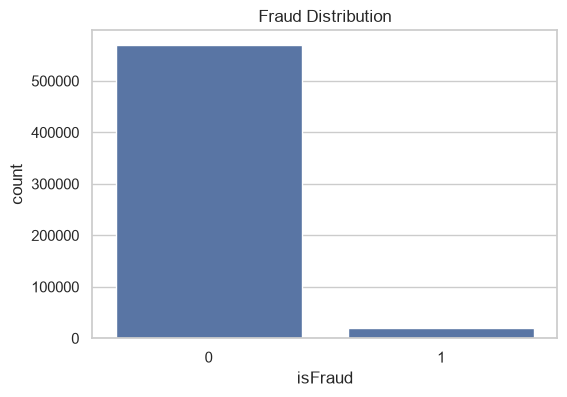

In [9]:
# Check class distribution of the target variable
df["isFraud"].value_counts()

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="isFraud"
)

plt.title("Fraud Distribution")
plt.show()



In [10]:
# Calculate fraud rate
fraud_rate = df["isFraud"].mean()*100
print(f"Fraud Rate: {fraud_rate:.2f}%")

Fraud Rate: 3.50%


### 7. Numerical Feature Analysis

In [11]:
# 7. Numerical Feature Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [12]:
# Identify numerical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print(f"Number of numerical features: {len(numerical_cols)}")

print(numerical_cols[:50])

Number of numerical features: 403
['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'card1', 'card2', 'card3', 'card5', 'addr1', 'addr2', 'dist1', 'dist2', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7', 'C8', 'C9', 'C10', 'C11', 'C12', 'C13', 'C14', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'D10', 'D11', 'D12', 'D13', 'D14', 'D15', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']


In [13]:
# Since TransactionID is only an identifier and isFraud is the target, exclude them from general predictor analysis:

numerical_features = [
    col for col in numerical_cols
    if col not in ["TransactionID", "isFraud"]
]

print(f"Numerical predictor features: {len(numerical_features)}")

Numerical predictor features: 401


In [14]:
# Summary statistics for key numerical features

In [15]:
key_numerical_features = [
    "TransactionAmt",
    "TransactionDT",
    "card1",
    "card2",
    "card3",
    "card5",
    "addr1",
    "addr2",
    "dist1",
    "dist2"
]

available_key_features = [
    col for col in key_numerical_features
    if col in df.columns
]

df[available_key_features].describe().T

,count,mean,std,min,25%,50%,75%,max
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.0,3.193739e+04
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.0,1.581113e+07
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.0,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.0,6.000000e+02
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.0,2.310000e+02
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.0,2.370000e+02
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.0,5.400000e+02
addr2,524834.0,8.680063e+01,2.690623e+00,10.000,87.000,87.000,87.0,1.020000e+02
dist1,238269.0,1.185022e+02,3.718720e+02,0.000,3.000,8.000,24.0,1.028600e+04
dist2,37627.0,2.318554e+02,5.290535e+02,0.000,7.000,37.000,206.0,1.162300e+04


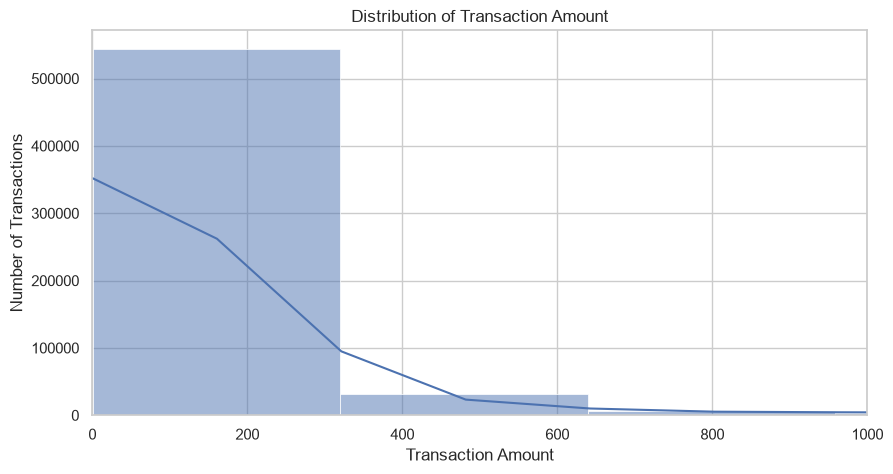

In [16]:
# Transaction amount distribution

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="TransactionAmt",
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")
plt.xlim(0, 1000)

plt.show()

Most transactions are concentrated at lower monetary values, while relatively few transactions involve large amounts. The distribution of transaction amounts is highly right-skewed (positively skewed), indicating the presence of extreme values (outliers). This suggests that transformations such as logarithmic scaling may improve the performance of certain machine learning algorithms that are sensitive to skewed feature distributions.

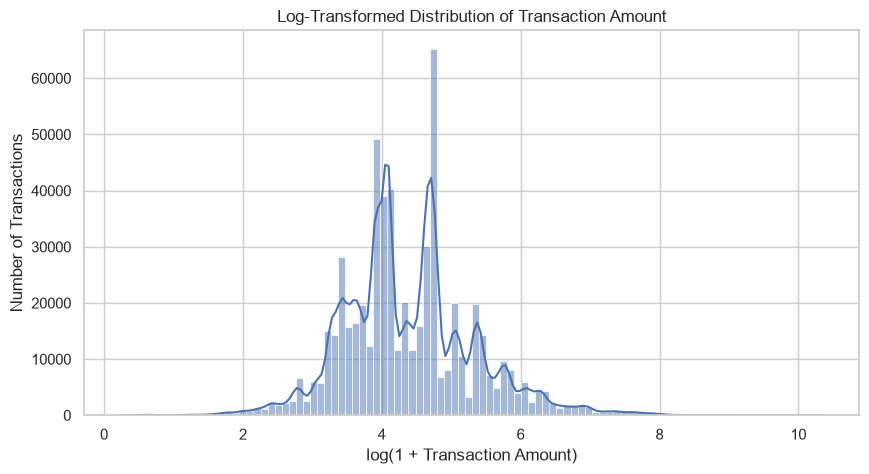

In [17]:
# Log-transformed transaction amount : This is useful because TransactionAmt is strongly right-skewed.

df["TransactionAmt_log"] = np.log1p(df["TransactionAmt"])

plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="TransactionAmt_log",
    bins=100,
    kde=True
)

plt.title("Log-Transformed Distribution of Transaction Amount")
plt.xlabel("log(1 + Transaction Amount)")
plt.ylabel("Number of Transactions")

plt.show()

#### Transaction amount by fraud class

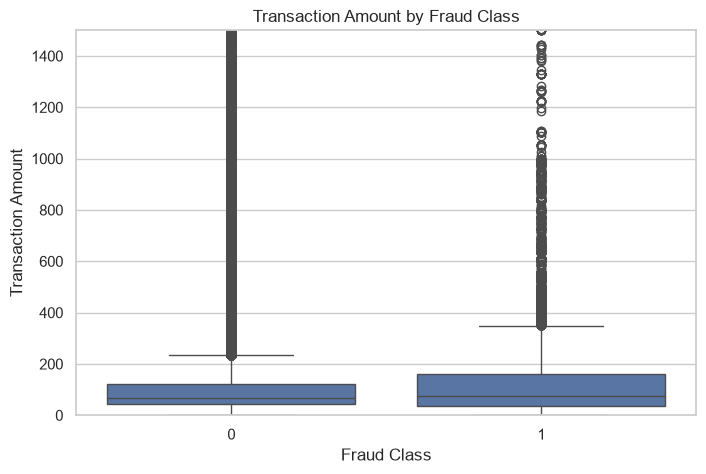

In [18]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="isFraud",
    y="TransactionAmt"
)

plt.title("Transaction Amount by Fraud Class")
plt.xlabel("Fraud Class")
plt.ylabel("Transaction Amount")
plt.ylim(0, 1500)

plt.show()

In [19]:
df.groupby("isFraud")["TransactionAmt"].agg(
    count="count",
    mean="mean",
    median="median",
    std="std",
    minimum="min",
    maximum="max"
).round(2)

,count,mean,median,std,minimum,maximum
isFraud,,,,,,
0,569877,134.51,68.5,239.40,0.25,31937.39
1,20663,149.24,75.0,232.21,0.29,5191.00


#### Fraud rate by transaction amount band

In [20]:
amount_bins = [
    0,
    25,
    50,
    100,
    200,
    500,
    1000,
    np.inf
]

amount_labels = [
    "0–25",
    "25–50",
    "50–100",
    "100–200",
    "200–500",
    "500–1000",
    "1000+"
]

df["TransactionAmt_band"] = pd.cut(
    df["TransactionAmt"],
    bins=amount_bins,
    labels=amount_labels,
    include_lowest=True
)

amount_fraud_summary = (
    df.groupby("TransactionAmt_band", observed=False)
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

amount_fraud_summary["fraud_rate_pct"] = (
    amount_fraud_summary["fraud_rate"] * 100
)

amount_fraud_summary



,TransactionAmt_band,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
0,0–25,50829,3150,0.061972,6.197250
1,25–50,153695,4683,0.030469,3.046944
2,50–100,164095,4788,0.029178,2.917822
3,100–200,128041,3899,0.030451,3.045118
4,200–500,71001,3135,0.044154,4.415431
5,500–1000,15612,829,0.053100,5.310018
6,1000+,7267,179,0.024632,2.463190


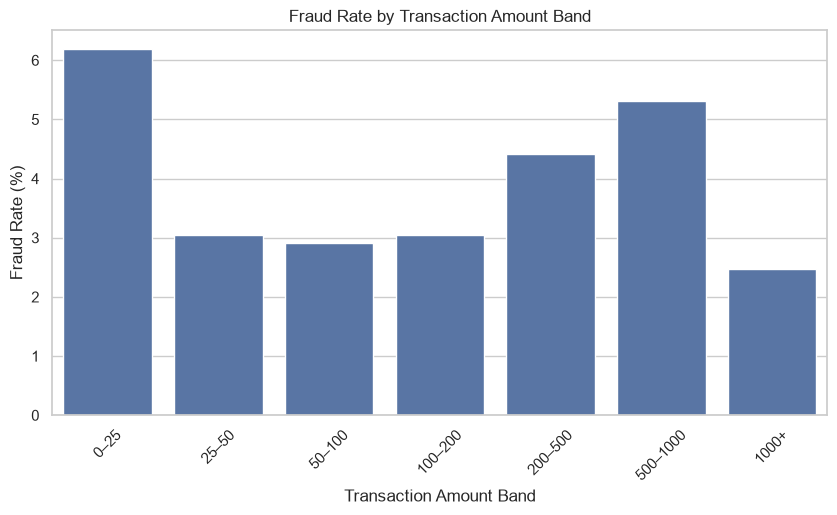

In [21]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=amount_fraud_summary,
    x="TransactionAmt_band",
    y="fraud_rate_pct"
)

plt.title("Fraud Rate by Transaction Amount Band")
plt.xlabel("Transaction Amount Band")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.show()

#### Transaction time analysis

In [22]:
# TransactionDT is measured in seconds from a reference point, not as a standard timestamp. Convert it into elapsed days and hours.

df["TransactionDay"] = df["TransactionDT"] / (60 * 60 * 24)
df["TransactionHour"] = (df["TransactionDT"] // 3600) % 24



#### Transactions over elapsed time

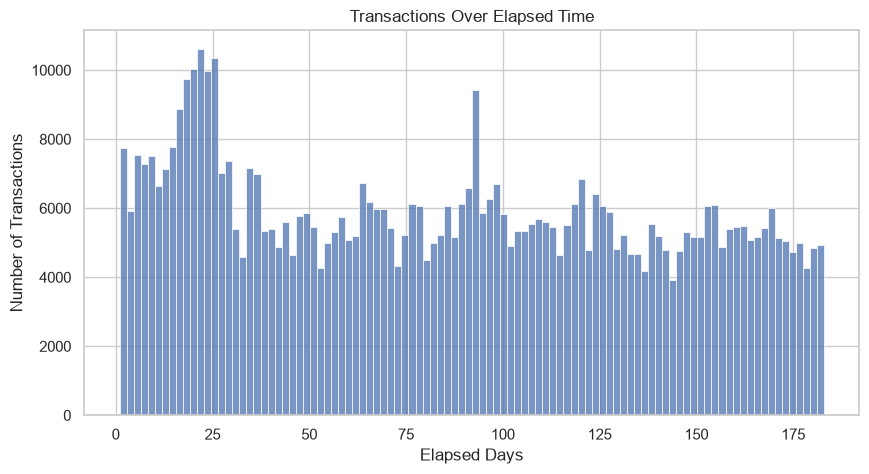

In [23]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="TransactionDay",
    bins=100
)

plt.title("Transactions Over Elapsed Time")
plt.xlabel("Elapsed Days")
plt.ylabel("Number of Transactions")

plt.show()

#### Fraud rate by hour

In [24]:
hourly_fraud = (
    df.groupby("TransactionHour")
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

hourly_fraud["fraud_rate_pct"] = hourly_fraud["fraud_rate"] * 100

hourly_fraud.head()

,TransactionHour,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
0,0,37795,1186,0.031380,3.137981
1,1,32797,1027,0.031314,3.131384
2,2,26732,1002,0.037483,3.748317
3,3,20802,797,0.038314,3.831362
4,4,14839,770,0.051890,5.189029


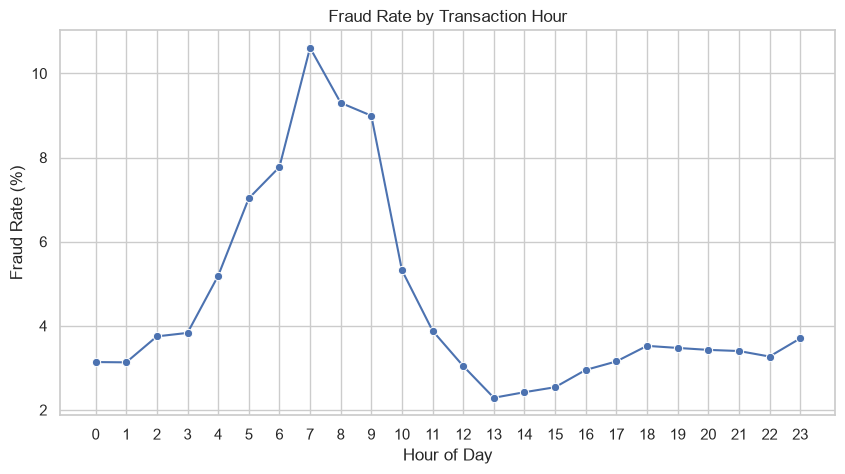

In [25]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_fraud,
    x="TransactionHour",
    y="fraud_rate_pct",
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(0, 24))

plt.show()

#### Distance-feature analysis

In [26]:
distance_features = [
    col for col in ["dist1", "dist2"]
    if col in df.columns
]

df.groupby("isFraud")[distance_features].median().round(2)

,dist1,dist2
isFraud,,
0,8.0,36.0
1,10.0,49.0


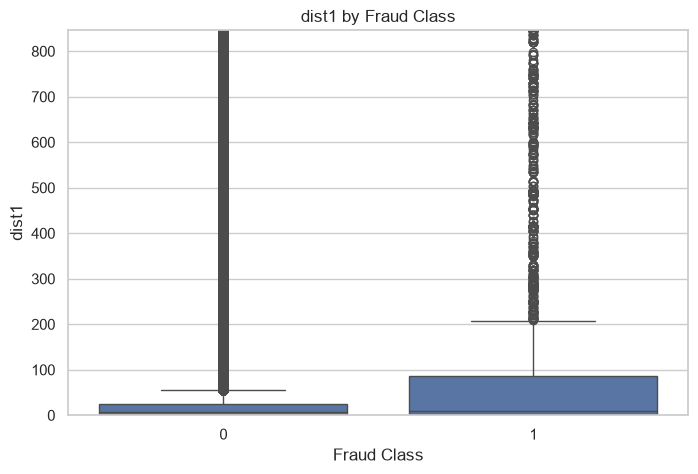

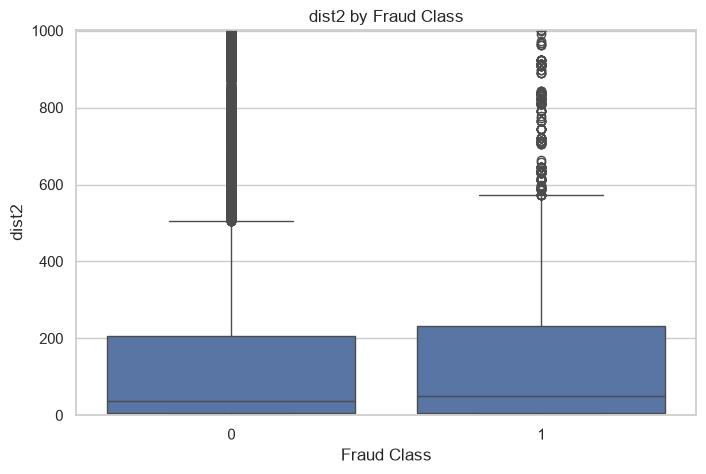

In [27]:
for feature in distance_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="isFraud",
        y=feature
    )

    plt.title(f"{feature} by Fraud Class")
    plt.xlabel("Fraud Class")
    plt.ylabel(feature)

    upper_limit = df[feature].quantile(0.95)

    if pd.notna(upper_limit):
        plt.ylim(0, upper_limit)

    plt.show()

#### C-feature comparison

In [28]:
# The C1–C14 columns are count-like variables. Compare their medians by fraud class:

c_features = [
    col for col in df.columns
    if col.startswith("C") and col[1:].isdigit()
]

c_summary = (
    df.groupby("isFraud")[c_features]
      .median()
      .T
      .rename(columns={
          0: "Non-Fraud Median",
          1: "Fraud Median"
      })
)

c_summary["Absolute Difference"] = (
    c_summary["Fraud Median"] -
    c_summary["Non-Fraud Median"]
).abs()

c_summary.sort_values(
    "Absolute Difference",
    ascending=False
).head(14)

isFraud,Non-Fraud Median,Fraud Median,Absolute Difference
C13,3.0,1.0,2.0
C1,1.0,2.0,1.0
C2,1.0,2.0,1.0
C4,0.0,1.0,1.0
C8,0.0,1.0,1.0
C9,1.0,0.0,1.0
C10,0.0,1.0,1.0
C11,1.0,2.0,1.0
C3,0.0,0.0,0.0
C5,0.0,0.0,0.0


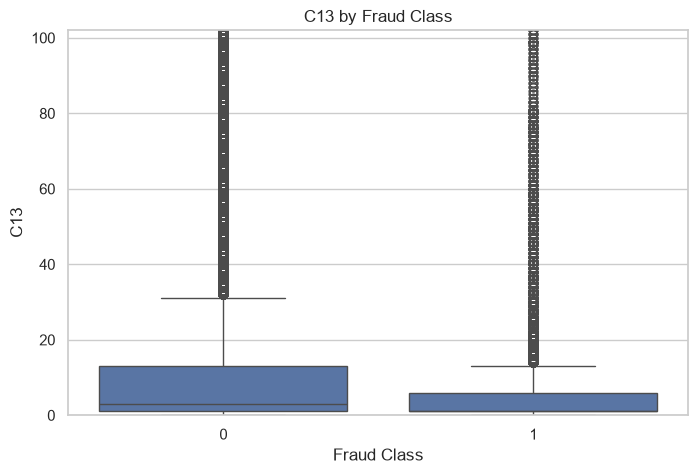

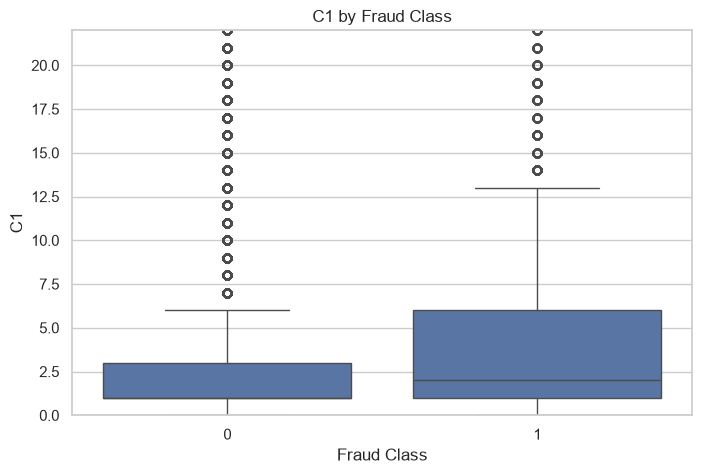

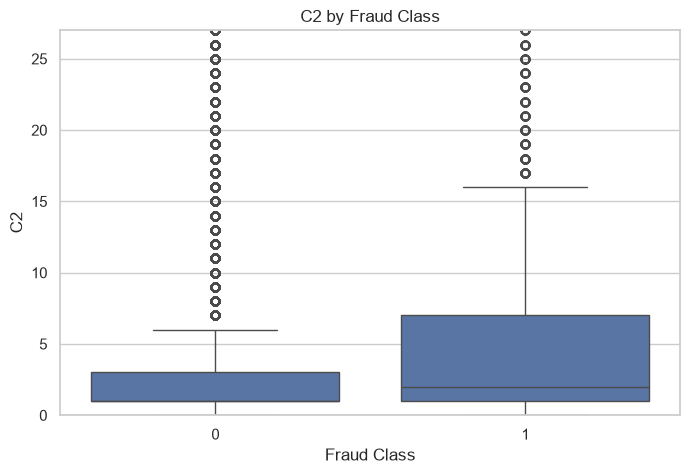

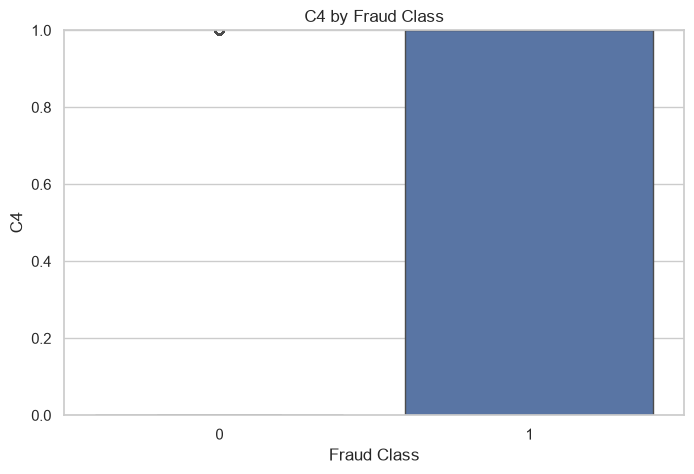

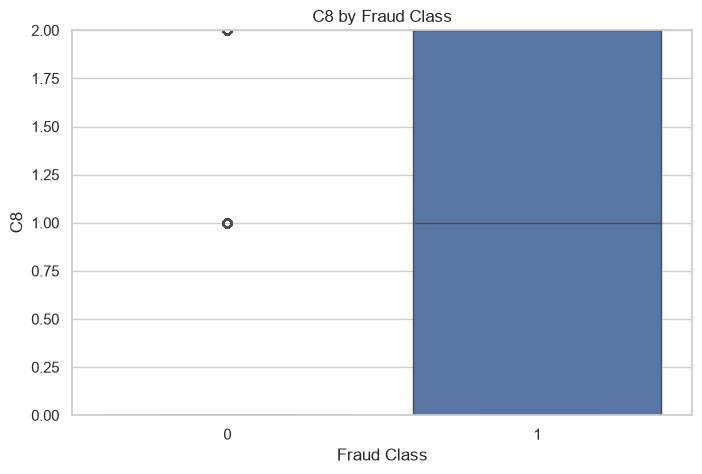

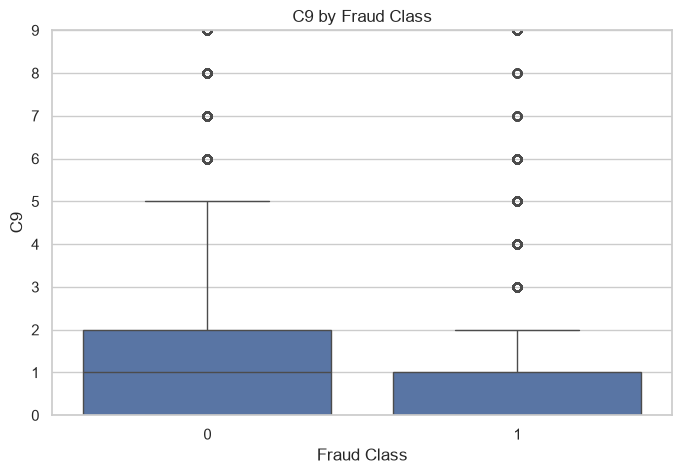

In [29]:
top_c_features = (
    c_summary.sort_values(
        "Absolute Difference",
        ascending=False
    )
    .head(6)
    .index
    .tolist()
)

for feature in top_c_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="isFraud",
        y=feature
    )

    plt.title(f"{feature} by Fraud Class")
    plt.xlabel("Fraud Class")
    plt.ylabel(feature)

    upper_limit = df[feature].quantile(0.95)

    if pd.notna(upper_limit):
        plt.ylim(0, upper_limit)

    plt.show()

#### D-feature comparison

In [30]:
d_features = [
    col for col in df.columns
    if col.startswith("D") and col[1:].isdigit()
]

d_summary = (
    df.groupby("isFraud")[d_features]
      .median()
      .T
      .rename(columns={
          0: "Non-Fraud Median",
          1: "Fraud Median"
      })
)

d_summary["Absolute Difference"] = (
    d_summary["Fraud Median"] -
    d_summary["Non-Fraud Median"]
).abs()

d_summary.sort_values(
    "Absolute Difference",
    ascending=False
).head(15)

isFraud,Non-Fraud Median,Fraud Median,Absolute Difference
D2,100.000000,16.000000,84.000000
D15,56.000000,1.000000,55.000000
D8,50.583332,2.666666,47.916666
D11,44.000000,7.000000,37.000000
D4,28.000000,1.000000,27.000000
D10,18.000000,0.000000,18.000000
D5,10.000000,0.000000,10.000000
D3,8.000000,1.000000,7.000000
D1,4.000000,0.000000,4.000000
D9,0.666666,0.625000,0.041666


In [31]:
# Since there are hundreds of numerical variables, we calculate correlations only with the target:

numeric_corr_with_fraud = (
    df[numerical_cols]
    .corr(numeric_only=True)["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

numeric_corr_with_fraud.head(20)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64

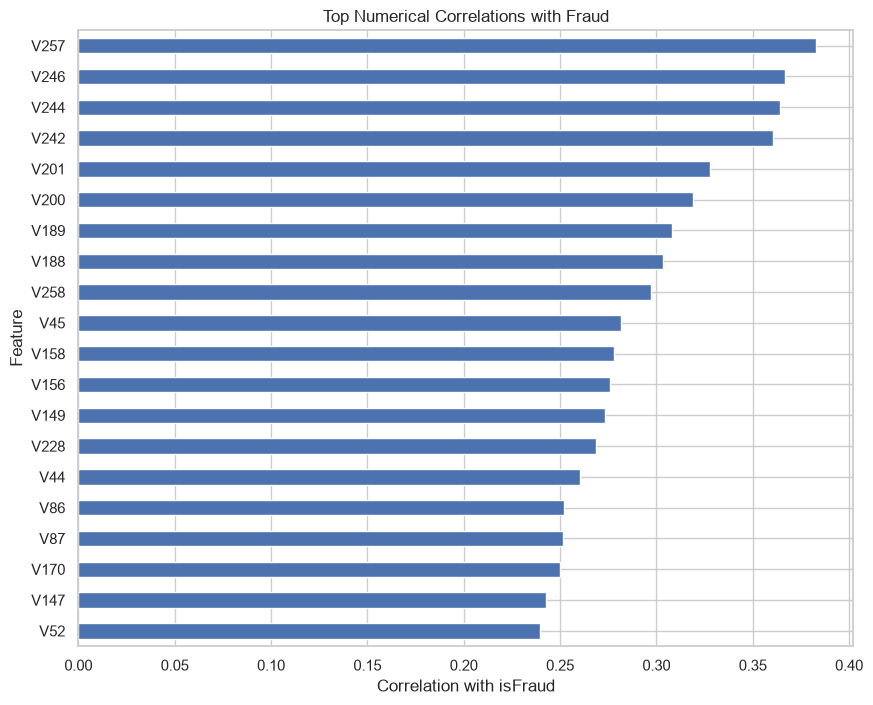

In [32]:
# Plot the top 20:
top_corr = numeric_corr_with_fraud.head(20).sort_values()

plt.figure(figsize=(10, 8))

top_corr.plot(kind="barh")

plt.title("Top Numerical Correlations with Fraud")
plt.xlabel("Correlation with isFraud")
plt.ylabel("Feature")

plt.show()


#### Numerical Feature Analysis Findings

- The dataset contains **403 numerical variables** (401 predictor variables after excluding `TransactionID` and the target variable `isFraud`), indicating a high-dimensional feature space suitable for advanced machine learning models.

- The `TransactionAmt` variable is **highly right-skewed**, with most transactions involving relatively small amounts and a small number of very large transactions. This distribution contains several extreme outliers.

- Because of this strong positive skewness, a **logarithmic transformation (`log1p`)** was applied to `TransactionAmt`, producing a more balanced distribution that is more appropriate for many machine learning algorithms.

- The presence of outliers suggests that robust preprocessing techniques, such as logarithmic transformation or robust scaling, may improve model stability while preserving potentially informative fraudulent transactions.

- Overall, the numerical analysis shows that the dataset contains substantial variation in transaction values and many continuous variables that can provide useful predictive information after appropriate preprocessing.

### 8. Categorical Features

#### 8.1 Identify categorical features

In [33]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print(f"Number of categorical features: {len(categorical_cols)}")
print(categorical_cols)

Number of categorical features: 31
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'id_12', 'id_15', 'id_16', 'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38', 'DeviceType', 'DeviceInfo']


#### 8.2 Missing values in categorical features

In [34]:
categorical_missing = (
    df[categorical_cols]
    .isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

categorical_missing = categorical_missing.reset_index()
categorical_missing.columns = ["Feature", "Missing (%)"]

categorical_missing.head(15)

,Feature,Missing (%)
0,id_27,99.124699
1,id_23,99.124699
2,id_33,87.589494
3,id_30,86.865411
4,id_34,86.824771
5,DeviceInfo,79.905510
6,id_16,78.098012
7,R_emaildomain,76.751617
8,id_31,76.245132
9,DeviceType,76.155722


#### 8.3 Cardinality (number of unique values)

In [35]:
categorical_cardinality = (
    df[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
)

categorical_cardinality

DeviceInfo       1786
id_33             260
id_31             130
id_30              75
R_emaildomain      60
P_emaildomain      59
ProductCD           5
id_34               4
card4               4
card6               4
id_15               3
id_23               3
M4                  3
M2                  2
DeviceType          2
id_38               2
id_37               2
id_36               2
id_35               2
M1                  2
M3                  2
id_29               2
id_27               2
id_16               2
id_12               2
M9                  2
M8                  2
M7                  2
M6                  2
M5                  2
id_28               2
dtype: int64

#### 8.4 Product Type (ProductCD)

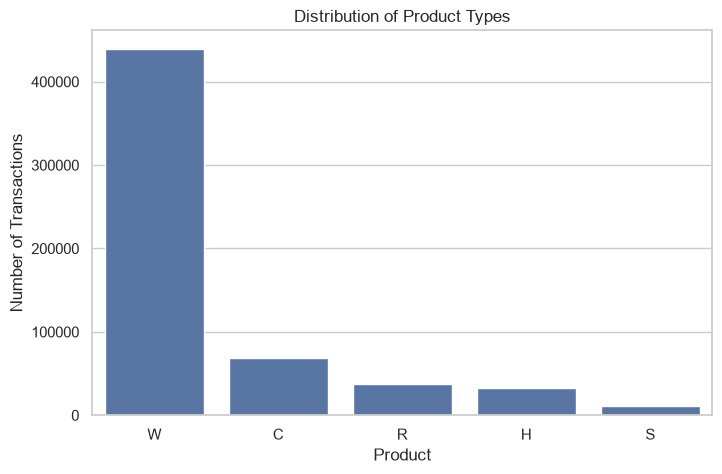

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="ProductCD",
    order=df["ProductCD"].value_counts().index
)

plt.title("Distribution of Product Types")
plt.xlabel("Product")
plt.ylabel("Number of Transactions")

plt.show()

##### Fraud by product:

In [37]:
product_fraud = (
    df.groupby("ProductCD")
      .agg(
          transaction_count=("TransactionID","count"),
          fraud_rate=("isFraud","mean")
      )
      .reset_index()
)

product_fraud["fraud_rate"] *= 100

product_fraud

,ProductCD,transaction_count,fraud_rate
0,C,68519,11.687269
1,H,33024,4.766231
2,R,37699,3.782594
3,S,11628,5.899553
4,W,439670,2.039939


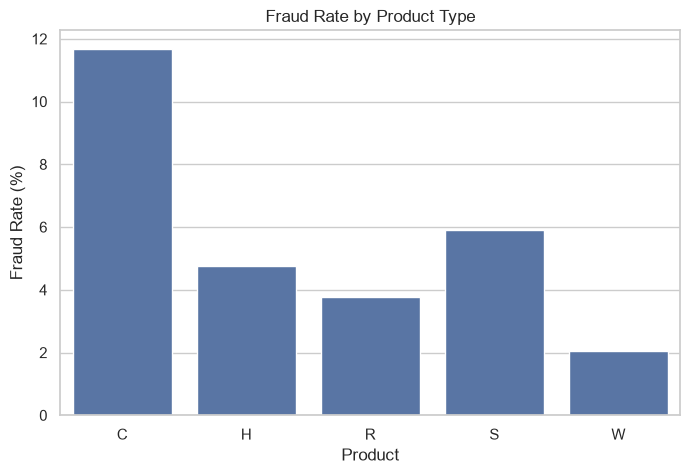

In [38]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=product_fraud,
    x="ProductCD",
    y="fraud_rate"
)

plt.title("Fraud Rate by Product Type")
plt.xlabel("Product")
plt.ylabel("Fraud Rate (%)")

plt.show()

#### 8.5 Card Network (card4)

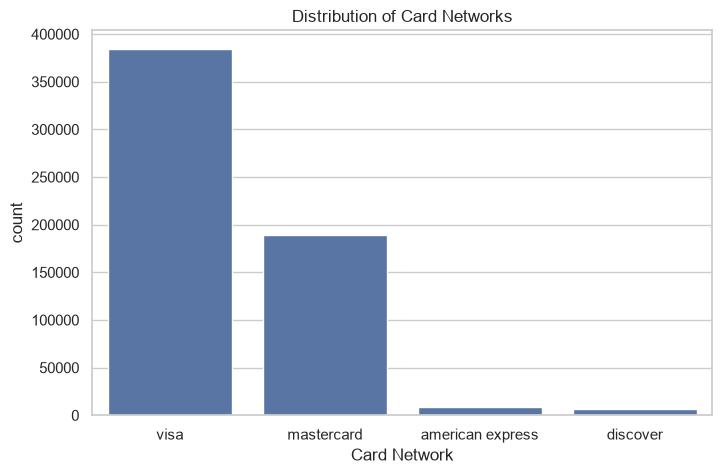

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="card4",
    order=df["card4"].value_counts().index
)

plt.title("Distribution of Card Networks")
plt.xlabel("Card Network")

plt.show()

##### Fraud rate:

In [40]:
card4_summary = (
    df.groupby("card4")
      .agg(
          transaction_count=("TransactionID","count"),
          fraud_rate=("isFraud","mean")
      )
      .reset_index()
)

card4_summary["fraud_rate"] *= 100

card4_summary

,card4,transaction_count,fraud_rate
0,american express,8328,2.869837
1,discover,6651,7.728161
2,mastercard,189217,3.433095
3,visa,384767,3.475610


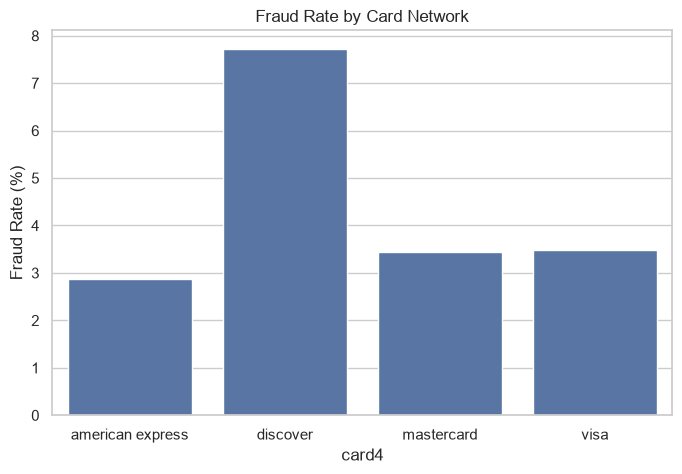

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=card4_summary,
    x="card4",
    y="fraud_rate"
)

plt.title("Fraud Rate by Card Network")
plt.ylabel("Fraud Rate (%)")

plt.show()

#### 8.6 Card Type (card6)

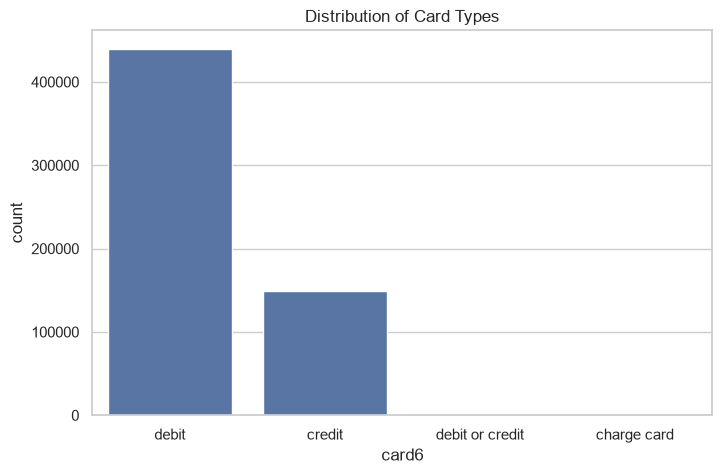

In [42]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="card6",
    order=df["card6"].value_counts().index
)

plt.title("Distribution of Card Types")

plt.show()

#### Fraud rate:

In [43]:
card6_summary = (
    df.groupby("card6")
      .agg(
          transaction_count=("TransactionID","count"),
          fraud_rate=("isFraud","mean")
      )
      .reset_index()
)

card6_summary["fraud_rate"] *= 100

card6_summary

,card6,transaction_count,fraud_rate
0,charge card,15,0.000000
1,credit,148986,6.678480
2,debit,439938,2.426251
3,debit or credit,30,0.000000


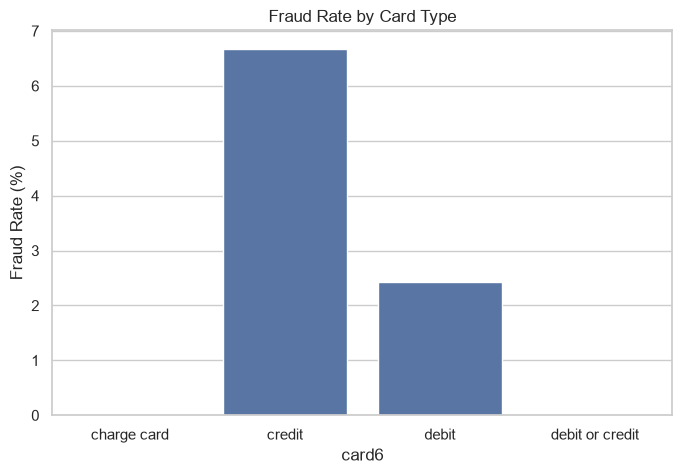

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=card6_summary,
    x="card6",
    y="fraud_rate"
)

plt.title("Fraud Rate by Card Type")
plt.ylabel("Fraud Rate (%)")

plt.show()

#### 8.7 Purchaser Email Domain

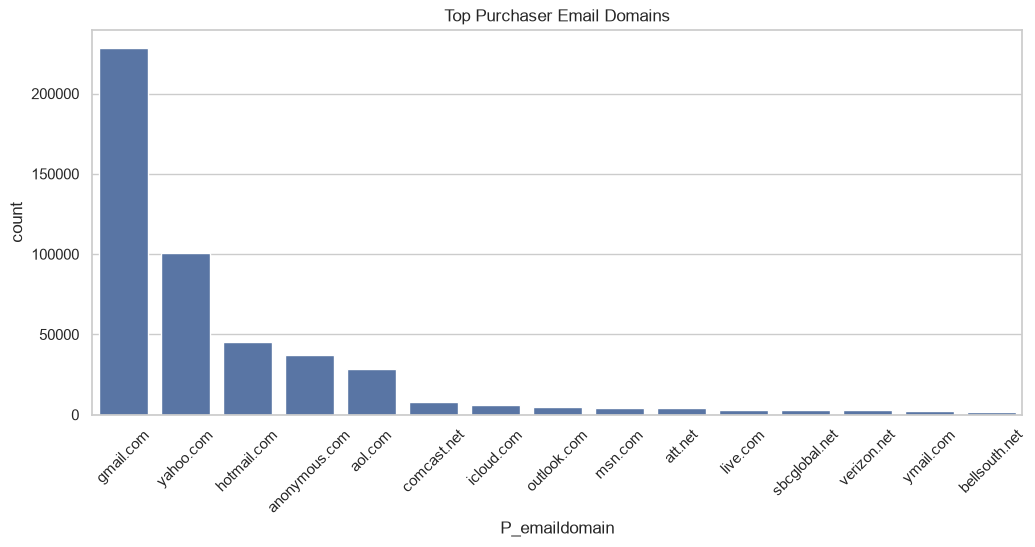

In [45]:
# Display only the 15 most frequent domains.
top_domains = (
    df["P_emaildomain"]
    .value_counts()
    .head(15)
    .index
)

plt.figure(figsize=(12,5))

sns.countplot(
    data=df[df["P_emaildomain"].isin(top_domains)],
    x="P_emaildomain",
    order=top_domains
)

plt.xticks(rotation=45)

plt.title("Top Purchaser Email Domains")

plt.show()


##### Fraud rate:

In [46]:
email_summary = (
    df.groupby("P_emaildomain")
      .agg(
          transaction_count=("TransactionID","count"),
          fraud_rate=("isFraud","mean")
      )
      .query("transaction_count > 500")
      .sort_values("fraud_rate", ascending=False)
)

email_summary["fraud_rate"] *= 100

email_summary.head(15)

,transaction_count,fraud_rate
P_emaildomain,,
mail.com,559,18.962433
outlook.com,5096,9.458399
live.com.mx,749,5.473965
hotmail.com,45250,5.295028
gmail.com,228355,4.354185
icloud.com,6267,3.143450
comcast.net,7888,3.118661
charter.net,816,3.063725
bellsouth.net,1909,2.776323


#### 8.8 Device Type

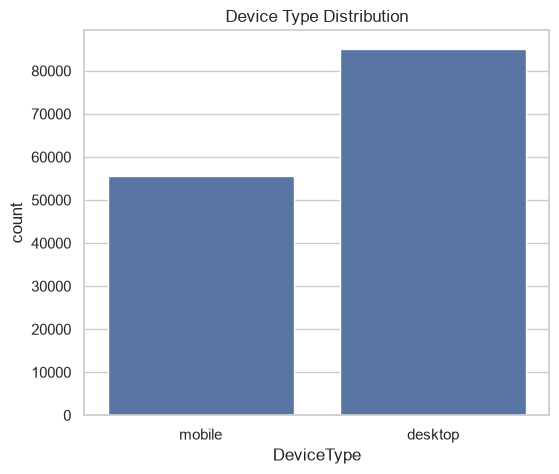

In [47]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="DeviceType"
)

plt.title("Device Type Distribution")

plt.show()

##### Fraud rate:

In [48]:
device_summary = (
    df.groupby("DeviceType")
      .agg(
          transaction_count=("TransactionID","count"),
          fraud_rate=("isFraud","mean")
      )
      .reset_index()
)

device_summary["fraud_rate"] *= 100

device_summary

,DeviceType,transaction_count,fraud_rate
0,desktop,85165,6.521458
1,mobile,55645,10.166232


#### 8.9 Device Information

Display the most common devices.

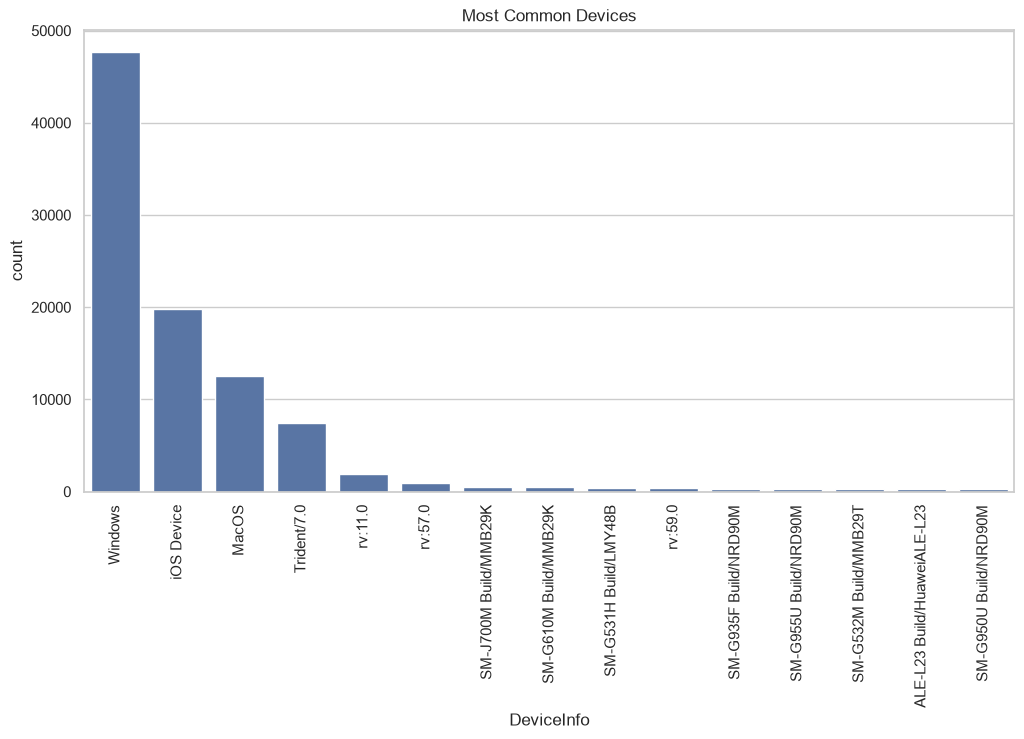

In [49]:
top_devices = (
    df["DeviceInfo"]
    .value_counts()
    .head(15)
    .index
)

plt.figure(figsize=(12,6))

sns.countplot(
    data=df[df["DeviceInfo"].isin(top_devices)],
    x="DeviceInfo",
    order=top_devices
)

plt.xticks(rotation=90)

plt.title("Most Common Devices")

plt.show()

#### 8.10 Summary Table

In [50]:
summary = pd.DataFrame({
    "Feature": categorical_cols,
    "Unique Values": [df[col].nunique() for col in categorical_cols],
    "Missing (%)": [df[col].isna().mean()*100 for col in categorical_cols]
})

summary.sort_values("Missing (%)", ascending=False)

,Feature,Unique Values,Missing (%)
18,id_27,2,99.124699
17,id_23,3,99.124699
23,id_33,260,87.589494
21,id_30,75,86.865411
24,id_34,4,86.824771
30,DeviceInfo,1786,79.905510
16,id_16,2,78.098012
4,R_emaildomain,60,76.751617
22,id_31,130,76.245132
29,DeviceType,2,76.155722


#### Categorical Feature Analysis Findings

- The dataset contains **31 categorical variables**, representing product categories, payment methods, email domains, device characteristics, and identity-related attributes.

- Several categorical variables exhibit **high cardinality**, particularly `DeviceInfo` and email domain features, indicating a large variety of unique values that may require encoding techniques such as frequency encoding or target encoding.

- Identity-related variables contain substantial missing values, suggesting that not all transactions include complete device or identity information.

- Product categories, payment card characteristics, and device information display different fraud rates, indicating that these variables may contribute meaningful predictive information for fraud detection.

- Overall, categorical variables are expected to play a significant role in the predictive performance of the fraud detection models after appropriate preprocessing and encoding.



### 9. Missing Values

#### 9.1 Overall Missing Values

In [51]:
# Total missing values in the dataset

missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing (%)": (df.isnull().mean() * 100).round(2)
})

missing_summary = (
    missing_summary
    .sort_values("Missing (%)", ascending=False)
)

missing_summary.head(20)

,Missing Values,Missing (%)
id_24,585793,99.20
id_26,585377,99.13
id_21,585381,99.13
id_25,585408,99.13
id_07,585385,99.13
id_08,585385,99.13
id_27,585371,99.12
id_23,585371,99.12
id_22,585371,99.12
dist2,552913,93.63


#### 9.2 Missing Value Distribution

<Figure size 1200x800 with 0 Axes>

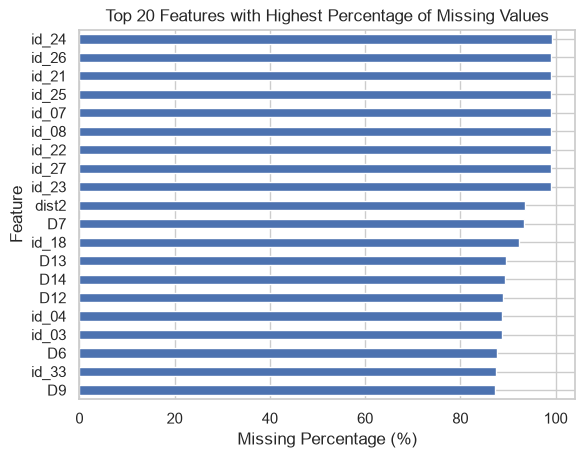

In [52]:
plt.figure(figsize=(12,8))

missing_summary.head(20).sort_values("Missing (%)").plot(
    kind="barh",
    y="Missing (%)",
    legend=False
)

plt.title("Top 20 Features with Highest Percentage of Missing Values")
plt.xlabel("Missing Percentage (%)")
plt.ylabel("Feature")

plt.show()

#### 9.3 Missing Value Categories

In [53]:
missing_ranges = pd.DataFrame({
    "Category": [
        "0%",
        "0–25%",
        "25–50%",
        "50–75%",
        "75–100%"
    ],
    "Number of Features": [
        (missing_summary["Missing (%)"] == 0).sum(),
        ((missing_summary["Missing (%)"] > 0) &
         (missing_summary["Missing (%)"] <= 25)).sum(),
        ((missing_summary["Missing (%)"] > 25) &
         (missing_summary["Missing (%)"] <= 50)).sum(),
        ((missing_summary["Missing (%)"] > 50) &
         (missing_summary["Missing (%)"] <= 75)).sum(),
        (missing_summary["Missing (%)"] > 75).sum()
    ]
})

missing_ranges

,Category,Number of Features
0,0%,56
1,0–25%,130
2,25–50%,38
3,50–75%,6
4,75–100%,208


#### 9.4 Plot Missing Value Categories

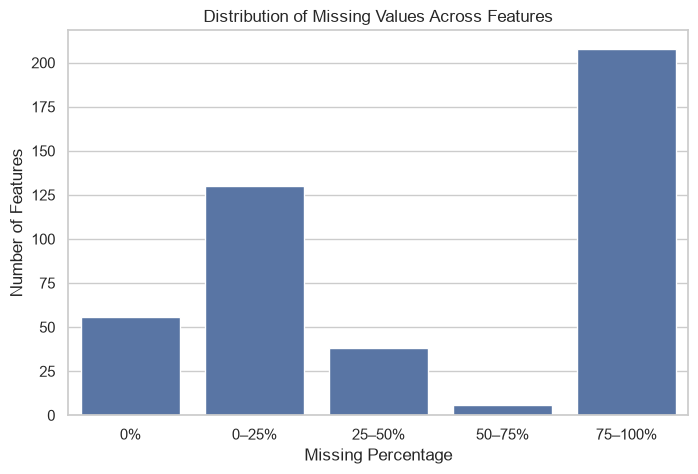

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=missing_ranges,
    x="Category",
    y="Number of Features"
)

plt.title("Distribution of Missing Values Across Features")
plt.xlabel("Missing Percentage")
plt.ylabel("Number of Features")

plt.show()

#### 9.5 Missing Values by Data Type

In [55]:
missing_by_type = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing (%)": df.isnull().mean() * 100
})

missing_by_type.groupby("Data Type")["Missing (%)"].mean().round(2)

Data Type
category     0.00
float64     43.99
int64        0.00
str         61.97
Name: Missing (%), dtype: float64

#### 9.6 Features with More Than 90% Missing Values

In [56]:
high_missing = missing_summary[
    missing_summary["Missing (%)"] > 90
]

print(f"Number of features with >90% missing values: {len(high_missing)}")

high_missing

Number of features with >90% missing values: 12


,Missing Values,Missing (%)
id_24,585793,99.20
id_26,585377,99.13
id_21,585381,99.13
id_25,585408,99.13
id_07,585385,99.13
id_08,585385,99.13
id_27,585371,99.12
id_23,585371,99.12
id_22,585371,99.12
dist2,552913,93.63


#### 9.7 Missing Values in Important Features

In [57]:
important_features = [
    "TransactionAmt",
    "ProductCD",
    "card4",
    "card6",
    "P_emaildomain",
    "R_emaildomain",
    "DeviceType",
    "DeviceInfo"
]

important_missing = pd.DataFrame({
    "Missing (%)":
    (df[important_features]
        .isnull()
        .mean() * 100).round(2)
})

important_missing

,Missing (%)
TransactionAmt,0.00
ProductCD,0.00
card4,0.27
card6,0.27
P_emaildomain,15.99
R_emaildomain,76.75
DeviceType,76.16
DeviceInfo,79.91


#### 9.8 Missing Value Heatmap (Sample)

Because the dataset has 590,540 rows, plotting the entire dataset would be extremely slow. Instead, use a random sample.

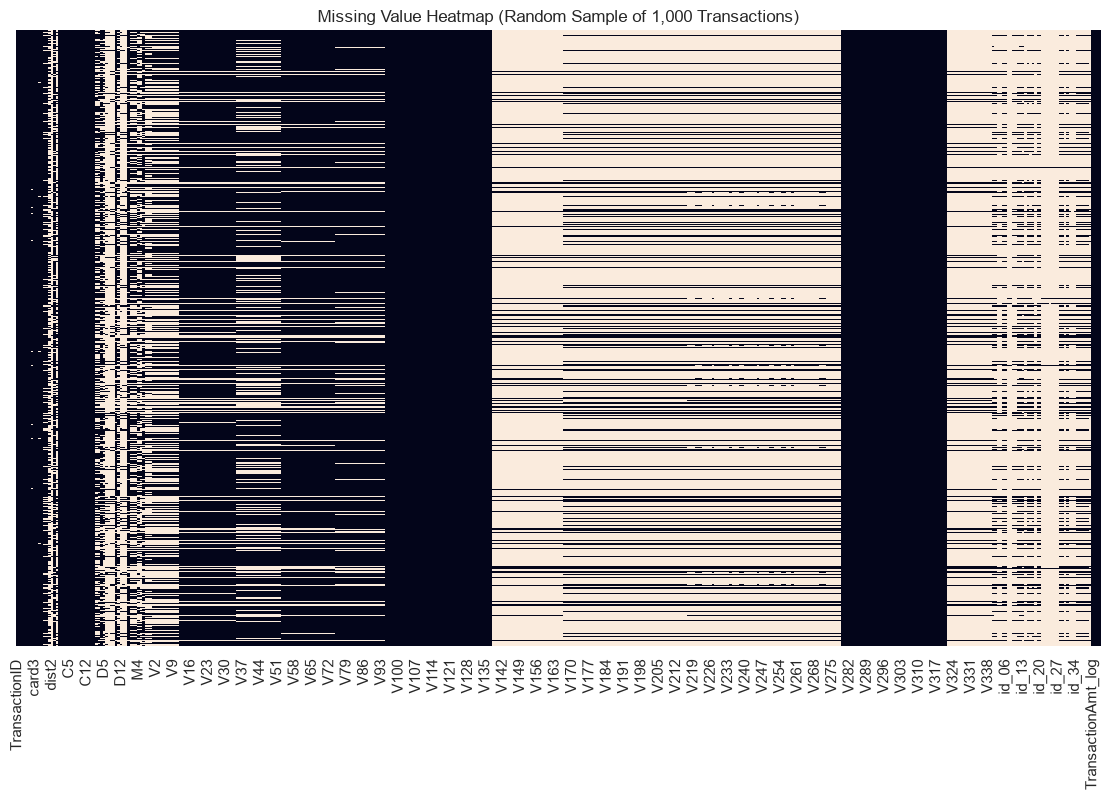

In [58]:
plt.figure(figsize=(14,8))

sns.heatmap(
    df.sample(1000, random_state=42).isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap (Random Sample of 1,000 Transactions)")

plt.show()

#### Missing Value Analysis Findings

- The IEEE-CIS Fraud Detection dataset contains a substantial number of missing values across many features, particularly among identity-related variables.

- Several features exhibit more than 75% missing values, indicating that missing data handling will be a critical step during preprocessing.

- Important transaction-related variables such as `TransactionAmt` and `ProductCD` contain few or no missing values, making them reliable predictors.

- Identity and device-related attributes (`DeviceInfo`, `DeviceType`, and various `id_` features) contain significantly higher proportions of missing values, suggesting that not all transactions include complete identity information.

- Appropriate missing value treatment strategies, including imputation and feature selection, will be applied before model development to maximize predictive performance while minimizing information loss.

### 10. Missing Values Treatment

In [59]:
# Proposed missing-value treatment strategy

missing_strategy = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Missing Count": df.isna().sum().values,
    "Missing (%)": (df.isna().mean() * 100).round(2).values,
    "Unique Values": df.nunique(dropna=True).values
})

#### 10.1. Define the treatment rules

In [60]:
def assign_missing_strategy(row):
    missing_pct = row["Missing (%)"]
    data_type = row["Data Type"]
    feature = row["Feature"]

    # Never treat the target or identifier as ordinary predictors
    if feature == "isFraud":
        return "Target — verify no missing values"

    if feature == "TransactionID":
        return "Identifier — exclude from model features"

    # Proposed removal threshold
    if missing_pct > 95:
        return "Candidate for removal"

    # No missing values
    if missing_pct == 0:
        return "No treatment required"

    # Categorical variables
    if data_type in ["object", "string", "category"]:
        return "Impute with 'Missing' category"

    # Numerical variables
    if missing_pct <= 50:
        return "Median imputation + missing indicator"

    # High but not extreme missingness
    return "Review individually; impute only if useful"

In [61]:
# Apply rules

missing_strategy["Proposed Treatment"] = missing_strategy.apply(
    assign_missing_strategy,
    axis=1
)

#### 10.2. Display the full strategy table

In [62]:
missing_strategy.sort_values(
    "Missing (%)",
    ascending=False
).head(50)

,Feature,Data Type,Missing Count,Missing (%),Unique Values,Proposed Treatment
417,id_24,float64,585793,99.20,12,Candidate for removal
419,id_26,float64,585377,99.13,95,Candidate for removal
414,id_21,float64,585381,99.13,490,Candidate for removal
418,id_25,float64,585408,99.13,341,Candidate for removal
400,id_07,float64,585385,99.13,84,Candidate for removal
401,id_08,float64,585385,99.13,94,Candidate for removal
420,id_27,str,585371,99.12,2,Candidate for removal
416,id_23,str,585371,99.12,3,Candidate for removal
415,id_22,float64,585371,99.12,25,Candidate for removal
14,dist2,float64,552913,93.63,1751,Review individually; impute only if useful


#### 10.3. Columns proposed for removal

In [63]:
columns_to_remove = missing_strategy.loc[
    missing_strategy["Proposed Treatment"] == "Candidate for removal",
    "Feature"
].tolist()

print(f"Number of candidate features for removal: {len(columns_to_remove)}")
print(columns_to_remove)

Number of candidate features for removal: 9
['id_07', 'id_08', 'id_21', 'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27']


#### 10.4. Categorical columns proposed for imputation

In [64]:
categorical_columns_to_impute = missing_strategy.loc[
    missing_strategy["Proposed Treatment"] == "Impute with 'Missing' category",
    "Feature"
].tolist()

print(
    f"Categorical features proposed for imputation: "
    f"{len(categorical_columns_to_impute)}"
)

print(categorical_columns_to_impute)

Categorical features proposed for imputation: 0
[]


#### 10.5. Numerical columns proposed for median imputation

In [65]:
numerical_columns_to_impute = missing_strategy.loc[
    missing_strategy["Proposed Treatment"] ==
    "Median imputation + missing indicator",
    "Feature"
].tolist()

print(
    f"Numerical features proposed for median imputation: "
    f"{len(numerical_columns_to_impute)}"
)

print(numerical_columns_to_impute)

Numerical features proposed for median imputation: 168
['card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'D1', 'D2', 'D3', 'D4', 'D10', 'D11', 'D15', 'M1', 'M2', 'M3', 'M4', 'M6', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95', 'V96', 'V97', 'V98', 'V99', 'V100', 'V101', 'V102', 'V103', 'V104', 'V105', 'V106', 'V107', 'V108', 'V109', 'V110', 'V111', 'V112', '

#### 10.6. Features requiring manual review

In [66]:
columns_to_review = missing_strategy.loc[
    missing_strategy["Proposed Treatment"] ==
    "Review individually; impute only if useful",
    "Feature"
].tolist()

print(f"Features requiring individual review: {len(columns_to_review)}")
print(columns_to_review)

Features requiring individual review: 205
['dist1', 'dist2', 'R_emaildomain', 'D5', 'D6', 'D7', 'D8', 'D9', 'D12', 'D13', 'D14', 'M5', 'M7', 'M8', 'M9', 'V138', 'V139', 'V140', 'V141', 'V142', 'V143', 'V144', 'V145', 'V146', 'V147', 'V148', 'V149', 'V150', 'V151', 'V152', 'V153', 'V154', 'V155', 'V156', 'V157', 'V158', 'V159', 'V160', 'V161', 'V162', 'V163', 'V164', 'V165', 'V166', 'V167', 'V168', 'V169', 'V170', 'V171', 'V172', 'V173', 'V174', 'V175', 'V176', 'V177', 'V178', 'V179', 'V180', 'V181', 'V182', 'V183', 'V184', 'V185', 'V186', 'V187', 'V188', 'V189', 'V190', 'V191', 'V192', 'V193', 'V194', 'V195', 'V196', 'V197', 'V198', 'V199', 'V200', 'V201', 'V202', 'V203', 'V204', 'V205', 'V206', 'V207', 'V208', 'V209', 'V210', 'V211', 'V212', 'V213', 'V214', 'V215', 'V216', 'V217', 'V218', 'V219', 'V220', 'V221', 'V222', 'V223', 'V224', 'V225', 'V226', 'V227', 'V228', 'V229', 'V230', 'V231', 'V232', 'V233', 'V234', 'V235', 'V236', 'V237', 'V238', 'V239', 'V240', 'V241', 'V242', 'V243',

#### 10.7. Summary of proposed decisions

In [67]:
strategy_summary = (
    missing_strategy["Proposed Treatment"]
    .value_counts()
    .rename_axis("Proposed Treatment")
    .reset_index(name="Number of Features")
)

strategy_summary

,Proposed Treatment,Number of Features
0,Review individually; impute only if useful,205
1,Median imputation + missing indicator,168
2,No treatment required,54
3,Candidate for removal,9
4,Identifier — exclude from model features,1
5,Target — verify no missing values,1


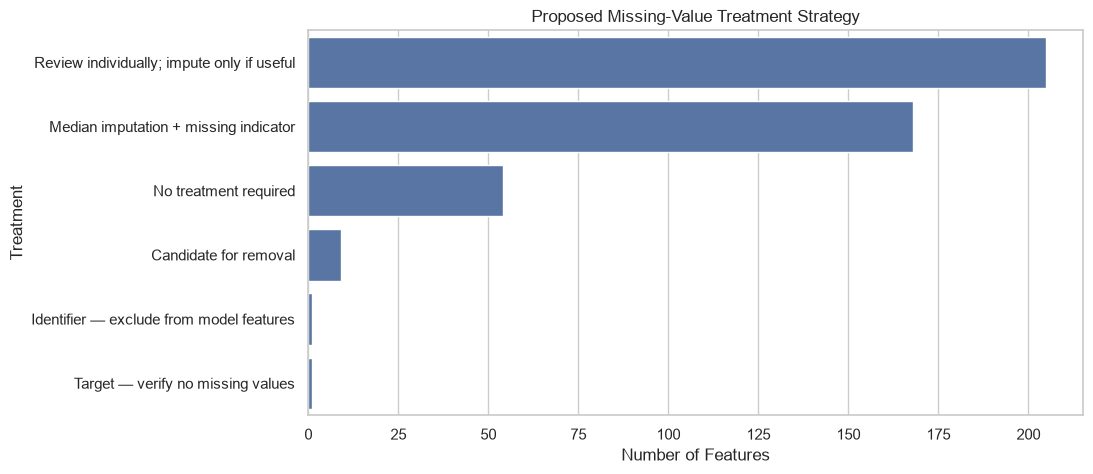

In [68]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=strategy_summary,
    x="Number of Features",
    y="Proposed Treatment"
)

plt.title("Proposed Missing-Value Treatment Strategy")
plt.xlabel("Number of Features")
plt.ylabel("Treatment")

plt.show()

#### 10.8. Decision table for report

In [69]:
decision_table = missing_strategy[
    missing_strategy["Missing (%)"] > 0
][
    [
        "Feature",
        "Data Type",
        "Missing Count",
        "Missing (%)",
        "Unique Values",
        "Proposed Treatment"
    ]
].sort_values(
    ["Proposed Treatment", "Missing (%)"],
    ascending=[True, False]
)

decision_table.head(50)

,Feature,Data Type,Missing Count,Missing (%),Unique Values,Proposed Treatment
417,id_24,float64,585793,99.20,12,Candidate for removal
400,id_07,float64,585385,99.13,84,Candidate for removal
401,id_08,float64,585385,99.13,94,Candidate for removal
414,id_21,float64,585381,99.13,490,Candidate for removal
418,id_25,float64,585408,99.13,341,Candidate for removal
419,id_26,float64,585377,99.13,95,Candidate for removal
415,id_22,float64,585371,99.12,25,Candidate for removal
416,id_23,str,585371,99.12,3,Candidate for removal
420,id_27,str,585371,99.12,2,Candidate for removal
49,M4,str,281444,47.66,3,Median imputation + missing indicator


#### Proposed Missing-Value Treatment

Features with more than 95% missing observations were identified as candidates for removal because their limited coverage may not provide sufficient information for reliable modelling. This threshold is treated as an initial screening rule rather than an automatic deletion criterion.

Categorical variables with missing observations will generally receive an explicit `Missing` category, preserving the possibility that absence of information itself carries predictive value. Numerical features with moderate missingness will generally be imputed using the training-set median and supplemented with binary missingness indicators.

Features with high, but not extreme, missingness will be reviewed individually using predictive importance, business relevance, and validation performance before a final decision is made.

### 11. Correlation Analysis

#### 11.1 Identify numerical predictors

In [70]:
# Identify numerical columns

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

numerical_predictors = [
    col for col in numerical_cols
    if col not in ["TransactionID", "isFraud"]
]

print(f"Numerical columns: {len(numerical_cols)}")
print(f"Numerical predictors: {len(numerical_predictors)}")

Numerical columns: 406
Numerical predictors: 404


#### 11.2 Correlation of numerical features with fraud

Because isFraud is binary, its Pearson correlation with a numerical feature is equivalent to the point-biserial correlation.

In [71]:
# Pearson correlation between numerical variables and the fraud target

correlation_with_fraud = (
    df[numerical_predictors + ["isFraud"]]
    .corr(method="pearson")["isFraud"]
    .drop("isFraud")
    .dropna()
    .sort_values(key=abs, ascending=False)
)

correlation_with_fraud.head(20)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64

#### 11.3 Table of strongest correlations

In [72]:
top_correlations = (
    correlation_with_fraud
    .head(20)
    .reset_index()
)

top_correlations.columns = [
    "Feature",
    "Correlation with isFraud"
]

top_correlations["Absolute Correlation"] = (
    top_correlations["Correlation with isFraud"].abs()
)

top_correlations

,Feature,Correlation with isFraud,Absolute Correlation
0,V257,0.383060,0.383060
1,V246,0.366878,0.366878
2,V244,0.364129,0.364129
3,V242,0.360590,0.360590
4,V201,0.328005,0.328005
5,V200,0.318783,0.318783
6,V189,0.308219,0.308219
7,V188,0.303582,0.303582
8,V258,0.297151,0.297151
9,V45,0.281832,0.281832


#### 11.4 Plot the top correlations with fraud

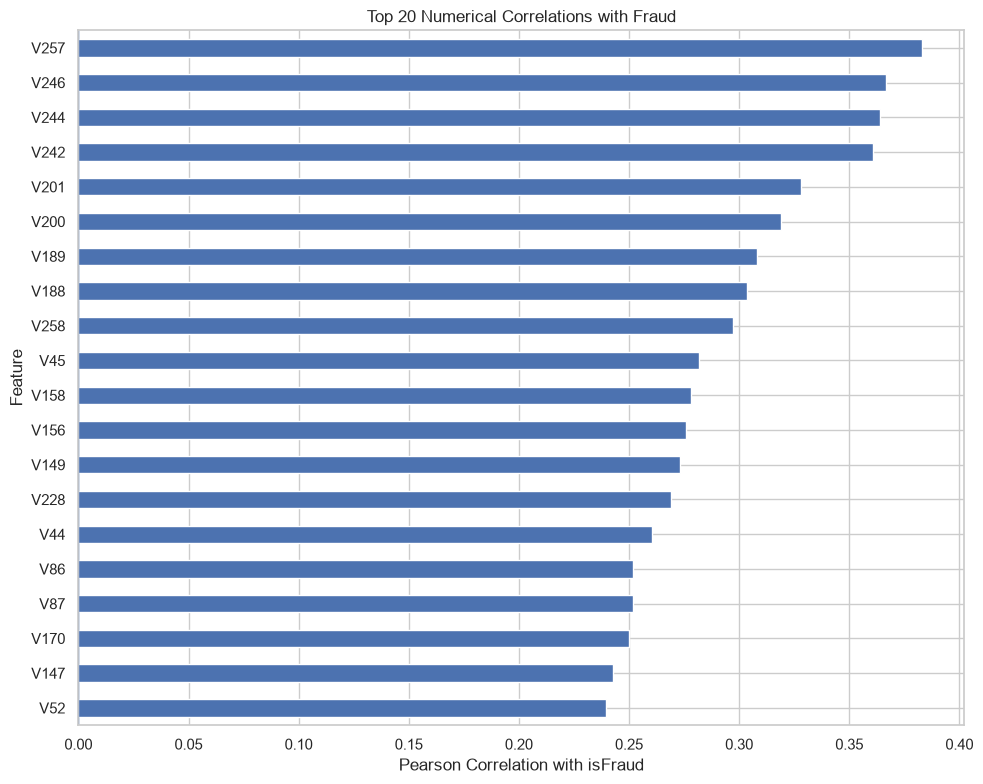

In [73]:
top_corr_plot = (
    correlation_with_fraud
    .head(20)
    .sort_values()
)

plt.figure(figsize=(10, 8))

top_corr_plot.plot(kind="barh")

plt.title("Top 20 Numerical Correlations with Fraud")
plt.xlabel("Pearson Correlation with isFraud")
plt.ylabel("Feature")
plt.axvline(0, linewidth=1)
plt.tight_layout()

plt.show()

A positive value means higher feature values tend to be associated with fraud. A negative value means higher values tend to be associated with legitimate transactions.

#### 11.5 Separate positive and negative correlations

In [74]:
strongest_positive = (
    correlation_with_fraud
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

strongest_positive.columns = [
    "Feature",
    "Correlation"
]

strongest_negative = (
    correlation_with_fraud
    .sort_values()
    .head(10)
    .reset_index()
)

strongest_negative.columns = [
    "Feature",
    "Correlation"
]

print("Strongest positive correlations:")
display(strongest_positive)

print("Strongest negative correlations:")
display(strongest_negative)

Strongest positive correlations:


,Feature,Correlation
0,V257,0.383060
1,V246,0.366878
2,V244,0.364129
3,V242,0.360590
4,V201,0.328005
5,V200,0.318783
6,V189,0.308219
7,V188,0.303582
8,V258,0.297151
9,V45,0.281832


Strongest negative correlations:


,Feature,Correlation
0,D8,-0.142636
1,D7,-0.127199
2,id_01,-0.120099
3,V48,-0.115786
4,V49,-0.110920
5,V90,-0.110168
6,V29,-0.107852
7,V91,-0.105453
8,V69,-0.104521
9,V30,-0.103088


#### 11.6 Focused correlation heatmap

Create a heatmap using only the predictors most strongly correlated with fraud.

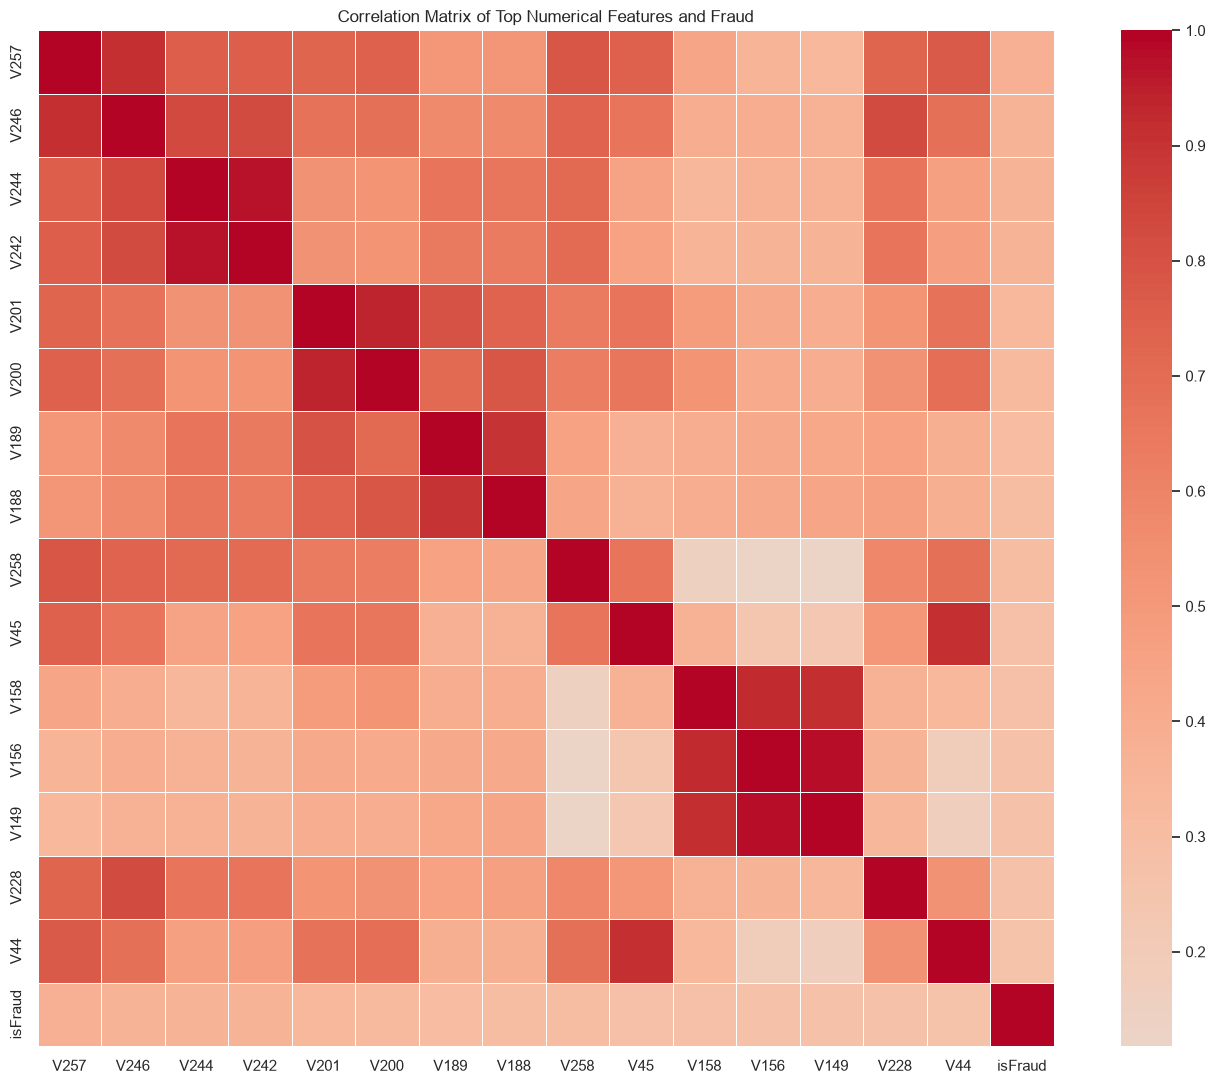

In [75]:
top_features = (
    correlation_with_fraud
    .head(15)
    .index
    .tolist()
)

focused_corr = df[top_features + ["isFraud"]].corr()

plt.figure(figsize=(14, 11))

sns.heatmap(
    focused_corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of Top Numerical Features and Fraud"
)

plt.tight_layout()
plt.show()

#### 11.7 Detect highly correlated predictor pairs

Highly correlated predictors may contain redundant information.

In [76]:
# Use the top 50 fraud-correlated predictors for a manageable redundancy check

selected_features = (
    correlation_with_fraud
    .head(50)
    .index
    .tolist()
)

predictor_corr = (
    df[selected_features]
    .corr()
    .abs()
)

# Keep only the upper triangle to avoid duplicate pairs
upper_triangle = predictor_corr.where(
    np.triu(
        np.ones(predictor_corr.shape),
        k=1
    ).astype(bool)
)

highly_correlated_pairs = (
    upper_triangle
    .stack()
    .reset_index()
)

highly_correlated_pairs.columns = [
    "Feature 1",
    "Feature 2",
    "Absolute Correlation"
]

highly_correlated_pairs = (
    highly_correlated_pairs[
        highly_correlated_pairs["Absolute Correlation"] >= 0.90
    ]
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
)

print(
    "Number of predictor pairs with absolute correlation >= 0.90:",
    len(highly_correlated_pairs)
)

highly_correlated_pairs.head(30)

Number of predictor pairs with absolute correlation >= 0.90: 50


,Feature 1,Feature 2,Absolute Correlation
2143,V17,V18,0.991474
1491,V154,V153,0.986471
562,V156,V149,0.976168
1074,V155,V148,0.975978
1940,V94,V33,0.975796
103,V244,V242,0.974318
2349,V92,V50,0.970760
2296,V93,V92,0.963108
1091,V155,V153,0.960661
2047,V33,V34,0.959243


#### 11.8 Correlation-strength summary

In [77]:
absolute_correlations = correlation_with_fraud.abs()

correlation_strength_summary = pd.DataFrame({
    "Correlation Strength": [
        "Very weak: < 0.10",
        "Weak: 0.10–0.30",
        "Moderate: 0.30–0.50",
        "Strong: ≥ 0.50"
    ],
    "Number of Features": [
        (absolute_correlations < 0.10).sum(),
        (
            (absolute_correlations >= 0.10) &
            (absolute_correlations < 0.30)
        ).sum(),
        (
            (absolute_correlations >= 0.30) &
            (absolute_correlations < 0.50)
        ).sum(),
        (absolute_correlations >= 0.50).sum()
    ]
})

correlation_strength_summary

,Correlation Strength,Number of Features
0,Very weak: < 0.10,285
1,Weak: 0.10–0.30,111
2,Moderate: 0.30–0.50,8
3,Strong: ≥ 0.50,0


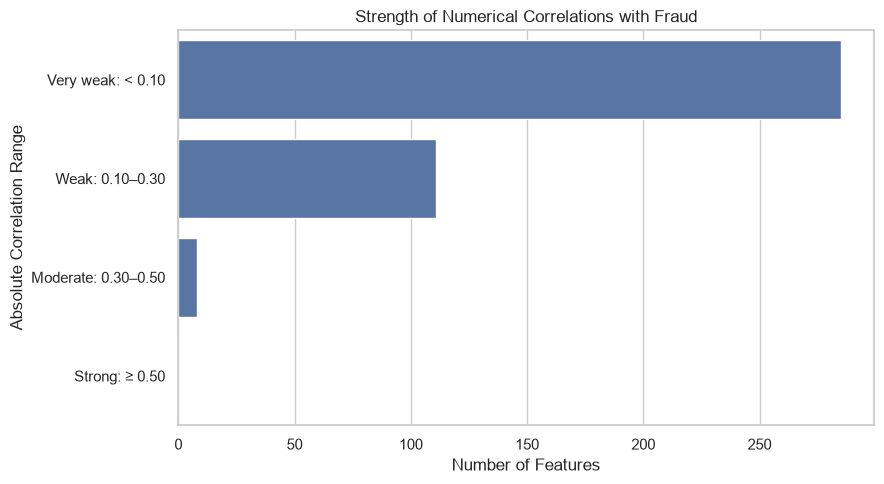

In [78]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=correlation_strength_summary,
    x="Number of Features",
    y="Correlation Strength"
)

plt.title("Strength of Numerical Correlations with Fraud")
plt.xlabel("Number of Features")
plt.ylabel("Absolute Correlation Range")
plt.tight_layout()

plt.show()

#### 11.9 Optional: Spearman correlation for key features

Pearson measures linear relationships. Spearman can detect monotonic relationships and is less sensitive to extreme values.

We only do this only for the top features rather than all numerical columns:

In [79]:
spearman_features = (
    correlation_with_fraud
    .head(20)
    .index
    .tolist()
)

spearman_with_fraud = (
    df[spearman_features + ["isFraud"]]
    .corr(method="spearman")["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

correlation_comparison = pd.DataFrame({
    "Pearson Correlation": correlation_with_fraud[
        spearman_features
    ],
    "Spearman Correlation": spearman_with_fraud[
        spearman_features
    ]
})

correlation_comparison["Pearson Absolute"] = (
    correlation_comparison["Pearson Correlation"].abs()
)

correlation_comparison.sort_values(
    "Pearson Absolute",
    ascending=False
).drop(columns="Pearson Absolute")

,Pearson Correlation,Spearman Correlation
V257,0.383060,0.387434
V246,0.366878,0.398693
V244,0.364129,0.404460
V242,0.360590,0.395531
V201,0.328005,0.282981
V200,0.318783,0.271738
V189,0.308219,0.256804
V188,0.303582,0.240248
V258,0.297151,0.385553
V45,0.281832,0.184659


#### Correlation Analysis Findings

- Most numerical predictors exhibit weak individual linear correlations with `isFraud`. This indicates that no single numerical variable provides sufficient separation between fraudulent and legitimate transactions.

- A limited group of variables shows comparatively stronger positive or negative relationships with fraud and should be retained for further modelling and feature-importance analysis.

- Several numerical predictors are strongly correlated with one another, indicating potential redundancy within the high-dimensional feature space. This may affect linear models through multicollinearity, although tree-based models are generally less sensitive to this issue.

- Weak Pearson correlation does not imply that a variable lacks predictive value. Fraud patterns may depend on nonlinear effects, threshold behaviour, missingness patterns, and interactions among transaction, card, identity, and device variables.

- Consequently, correlation analysis will be used as an exploratory and diagnostic tool rather than as the sole criterion for feature selection.

We do not automatically delete features merely because their target correlation is low. That would remove predictors involved in nonlinear relationships, which are common in fraud detection. Use validation performance and model-based feature importance later to make the final feature-selection decisions.

### 12. Business Insights

#### 12.1 Overall fraud exposure

In [80]:
# Overall fraud exposure

overall_fraud_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Fraudulent Transactions",
        "Legitimate Transactions",
        "Fraud Rate (%)",
        "Fraud-to-Legitimate Ratio"
    ],
    "Value": [
        len(df),
        int(df["isFraud"].sum()),
        int((df["isFraud"] == 0).sum()),
        round(df["isFraud"].mean() * 100, 2),
        round(
            df["isFraud"].sum() /
            (df["isFraud"] == 0).sum(),
            4
        )
    ]
})

overall_fraud_summary

,Metric,Value
0,Total Transactions,590540.0000
1,Fraudulent Transactions,20663.0000
2,Legitimate Transactions,569877.0000
3,Fraud Rate (%),3.5000
4,Fraud-to-Legitimate Ratio,0.0363


#### 12.2 Financial exposure by fraud class

In [81]:
# Transaction-value exposure by fraud class

fraud_value_summary = (
    df.groupby("isFraud")
      .agg(
          transaction_count=("TransactionID", "count"),
          total_transaction_value=("TransactionAmt", "sum"),
          average_transaction_value=("TransactionAmt", "mean"),
          median_transaction_value=("TransactionAmt", "median"),
          maximum_transaction_value=("TransactionAmt", "max")
      )
      .reset_index()
)

fraud_value_summary["Fraud Status"] = fraud_value_summary["isFraud"].map({
    0: "Legitimate",
    1: "Fraudulent"
})

fraud_value_summary[
    [
        "Fraud Status",
        "transaction_count",
        "total_transaction_value",
        "average_transaction_value",
        "median_transaction_value",
        "maximum_transaction_value"
    ]
].round(2)

,Fraud Status,transaction_count,total_transaction_value,average_transaction_value,median_transaction_value,maximum_transaction_value
0,Legitimate,569877,76655103.88,134.51,68.5,31937.39
1,Fraudulent,20663,3083844.86,149.24,75.0,5191.00


Calculate the percentage of transaction value associated with fraud:

In [82]:
fraudulent_value = df.loc[
    df["isFraud"] == 1,
    "TransactionAmt"
].sum()

total_value = df["TransactionAmt"].sum()

fraud_value_percentage = (
    fraudulent_value / total_value
) * 100

print(
    f"Fraudulent transactions represent "
    f"{fraud_value_percentage:.2f}% of total transaction value."
)

Fraudulent transactions represent 3.87% of total transaction value.


#### 12.3 Highest-risk product categories

In [83]:
# Fraud risk by product category

product_risk = (
    df.groupby("ProductCD", dropna=False)
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean"),
          total_value=("TransactionAmt", "sum"),
          fraudulent_value=(
              "TransactionAmt",
              lambda x: x[df.loc[x.index, "isFraud"] == 1].sum()
          )
      )
      .reset_index()
)

product_risk["fraud_rate_pct"] = (
    product_risk["fraud_rate"] * 100
)

product_risk.sort_values(
    "fraud_rate_pct",
    ascending=False
).round(2)

,ProductCD,transaction_count,fraud_count,fraud_rate,total_value,fraudulent_value,fraud_rate_pct
0,C,68519,8008,0.12,2937570.76,391421.40,11.69
3,S,11628,686,0.06,700813.60,43416.00,5.90
1,H,33024,1574,0.05,2416368.00,246632.00,4.77
2,R,37699,1426,0.04,6344975.00,348050.00,3.78
4,W,439670,8969,0.02,67339221.37,2054325.46,2.04


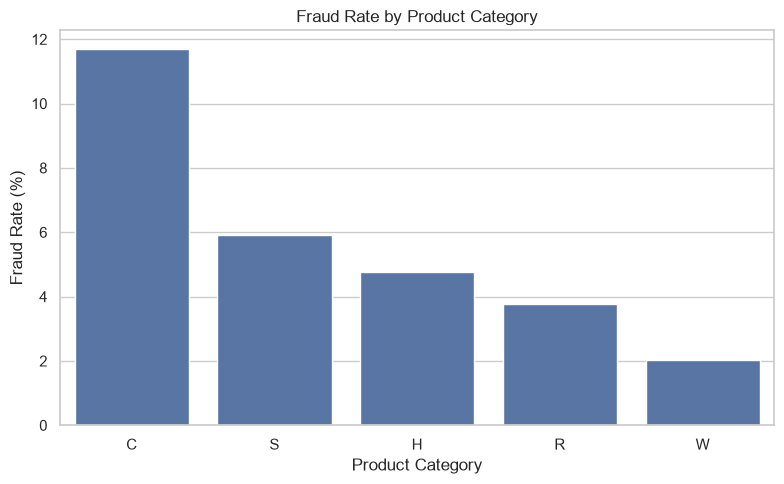

In [84]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=product_risk.sort_values(
        "fraud_rate_pct",
        ascending=False
    ),
    x="ProductCD",
    y="fraud_rate_pct"
)

plt.title("Fraud Rate by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Fraud Rate (%)")
plt.tight_layout()

plt.show()

#### 12.4 Highest-risk transaction amount bands

We use the TransactionAmt_band variable created earlier:

In [85]:
# Fraud risk by transaction amount band

amount_risk = (
    df.groupby(
        "TransactionAmt_band",
        observed=False
    )
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean"),
        total_transaction_value=("TransactionAmt", "sum"),
        fraudulent_value=(
            "TransactionAmt",
            lambda x: x[df.loc[x.index, "isFraud"] == 1].sum()
        )
    )
    .reset_index()
)

amount_risk["fraud_rate_pct"] = (
    amount_risk["fraud_rate"] * 100
)

amount_risk.round(2)

,TransactionAmt_band,transaction_count,fraud_count,fraud_rate,total_transaction_value,fraudulent_value,fraud_rate_pct
0,0–25,50829,3150,0.06,896532.28,50031.06,6.20
1,25–50,153695,4683,0.03,5969086.47,178310.99,3.05
2,50–100,164095,4788,0.03,11793998.25,355346.32,2.92
3,100–200,128041,3899,0.03,16967525.76,558680.71,3.05
4,200–500,71001,3135,0.04,20969859.34,1003252.81,4.42
5,500–1000,15612,829,0.05,10637374.08,637292.61,5.31
6,1000+,7267,179,0.02,12504572.55,300930.36,2.46


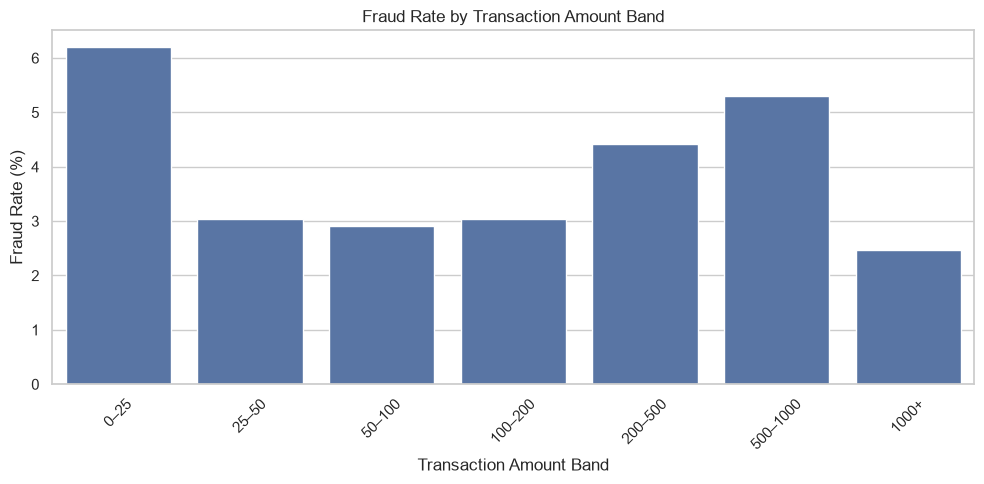

In [86]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=amount_risk,
    x="TransactionAmt_band",
    y="fraud_rate_pct"
)

plt.title("Fraud Rate by Transaction Amount Band")
plt.xlabel("Transaction Amount Band")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#### 12.5 Card-network risk

In [87]:
# Fraud risk by card network

card_network_risk = (
    df.groupby("card4", dropna=False)
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

card_network_risk["fraud_rate_pct"] = (
    card_network_risk["fraud_rate"] * 100
)

card_network_risk.sort_values(
    "fraud_rate_pct",
    ascending=False
).round(2)

,card4,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
1,discover,6651,514,0.08,7.73
3,visa,384767,13373,0.03,3.48
2,mastercard,189217,6496,0.03,3.43
0,american express,8328,239,0.03,2.87
4,NaN,1577,41,0.03,2.60


#### 12.6 Card-type risk

In [88]:
# Fraud risk by card type

card_type_risk = (
    df.groupby("card6", dropna=False)
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

card_type_risk["fraud_rate_pct"] = (
    card_type_risk["fraud_rate"] * 100
)

card_type_risk.sort_values(
    "fraud_rate_pct",
    ascending=False
).round(2)

,card6,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
1,credit,148986,9950,0.07,6.68
4,NaN,1571,39,0.02,2.48
2,debit,439938,10674,0.02,2.43
0,charge card,15,0,0.00,0.00
3,debit or credit,30,0,0.00,0.00


#### 12.7 Device-based fraud risk

In [89]:
# Fraud risk by device type

device_risk = (
    df.groupby("DeviceType", dropna=False)
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

device_risk["fraud_rate_pct"] = (
    device_risk["fraud_rate"] * 100
)

device_risk.sort_values(
    "fraud_rate_pct",
    ascending=False
).round(2)

,DeviceType,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
1,mobile,55645,5657,0.10,10.17
0,desktop,85165,5554,0.07,6.52
2,NaN,449730,9452,0.02,2.10


We treat missing device information as an explicit investigation signal:

In [90]:
df["DeviceInfoAvailable"] = np.where(
    df["DeviceInfo"].notna(),
    "Available",
    "Missing"
)

device_information_risk = (
    df.groupby("DeviceInfoAvailable")
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean")
      )
      .reset_index()
)

device_information_risk["fraud_rate_pct"] = (
    device_information_risk["fraud_rate"] * 100
)

device_information_risk.round(2)

,DeviceInfoAvailable,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
0,Available,118666,8607,0.07,7.25
1,Missing,471874,12056,0.03,2.55


#### 12.8 Identity-information availability

In [91]:
# Count the number of identity variables available for each transaction

identity_columns = [
    col for col in df.columns
    if col.startswith("id_")
]

df["IdentityFeaturesAvailable"] = (
    df[identity_columns]
    .notna()
    .sum(axis=1)
)

identity_availability_summary = (
    df.groupby("isFraud")["IdentityFeaturesAvailable"]
      .agg(
          mean="mean",
          median="median",
          minimum="min",
          maximum="max"
      )
      .rename(index={
          0: "Legitimate",
          1: "Fraudulent"
      })
)

identity_availability_summary.round(2)

,mean,median,minimum,maximum
isFraud,,,,
Legitimate,5.51,0.0,0,38
Fraudulent,12.84,19.0,0,38


Create availability bands:

In [92]:
df["IdentityAvailabilityBand"] = pd.cut(
    df["IdentityFeaturesAvailable"],
    bins=[-1, 0, 5, 10, 20, np.inf],
    labels=[
        "None",
        "1–5",
        "6–10",
        "11–20",
        "21+"
    ]
)

identity_risk = (
    df.groupby(
        "IdentityAvailabilityBand",
        observed=False
    )
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean")
    )
    .reset_index()
)

identity_risk["fraud_rate_pct"] = (
    identity_risk["fraud_rate"] * 100
)

identity_risk.round(2)

,IdentityAvailabilityBand,transaction_count,fraud_count,fraud_rate,fraud_rate_pct
0,None,446307,9345,0.02,2.09
1,1–5,3248,96,0.03,2.96
2,6–10,7,4,0.57,57.14
3,11–20,32618,2414,0.07,7.40
4,21+,108360,8804,0.08,8.12


#### 12.9 Time-based risk patterns

In [93]:
# Fraud risk by relative transaction hour

hourly_business_risk = (
    df.groupby("TransactionHour")
      .agg(
          transaction_count=("TransactionID", "count"),
          fraud_count=("isFraud", "sum"),
          fraud_rate=("isFraud", "mean"),
          fraudulent_value=(
              "TransactionAmt",
              lambda x: x[df.loc[x.index, "isFraud"] == 1].sum()
          )
      )
      .reset_index()
)

hourly_business_risk["fraud_rate_pct"] = (
    hourly_business_risk["fraud_rate"] * 100
)

hourly_business_risk.sort_values(
    "fraud_rate_pct",
    ascending=False
).head(10).round(2)

,TransactionHour,transaction_count,fraud_count,fraud_rate,fraudulent_value,fraud_rate_pct
7,7,3704,393,0.11,39466.93,10.61
8,8,2591,241,0.09,38833.63,9.30
9,9,2479,223,0.09,48447.96,9.00
6,6,6007,467,0.08,50704.91,7.77
5,5,9701,682,0.07,79136.28,7.03
10,10,3627,193,0.05,31333.13,5.32
4,4,14839,770,0.05,83123.13,5.19
11,11,6827,265,0.04,36448.50,3.88
3,3,20802,797,0.04,93367.78,3.83
2,2,26732,1002,0.04,122812.96,3.75


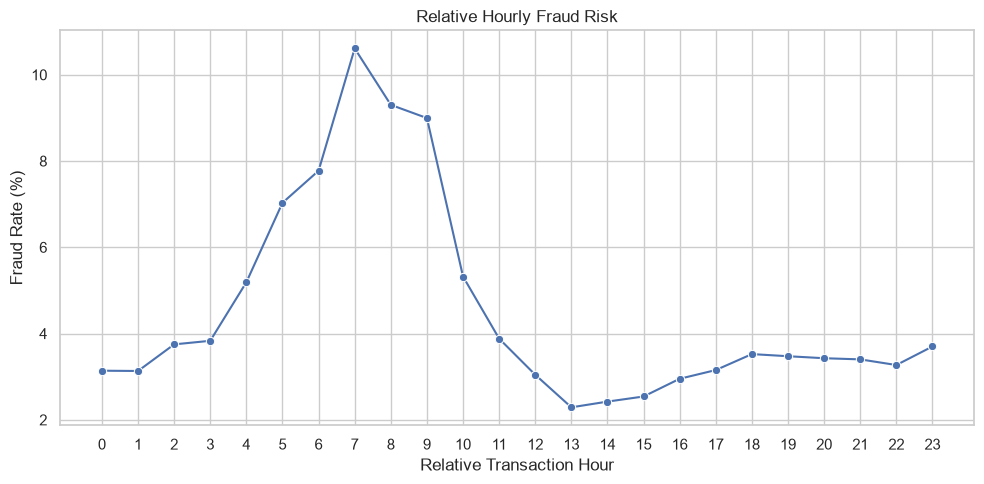

In [94]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hourly_business_risk,
    x="TransactionHour",
    y="fraud_rate_pct",
    marker="o"
)

plt.title("Relative Hourly Fraud Risk")
plt.xlabel("Relative Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.tight_layout()

plt.show()

# These are NOT confirmed local clock hours because TransactionDT starts from an undisclosed reference point.

#### 12.10 High-risk segment identification

This combines multiple business variables and avoids ranking tiny categories with unstable fraud rates.

In [95]:
# Identify high-risk transaction segments

segment_risk = (
    df.groupby(
        [
            "ProductCD",
            "card4",
            "card6",
            "DeviceType"
        ],
        dropna=False
    )
    .agg(
        transaction_count=("TransactionID", "count"),
        fraud_count=("isFraud", "sum"),
        fraud_rate=("isFraud", "mean"),
        average_amount=("TransactionAmt", "mean"),
        fraudulent_value=(
            "TransactionAmt",
            lambda x: x[df.loc[x.index, "isFraud"] == 1].sum()
        )
    )
    .reset_index()
)

segment_risk["fraud_rate_pct"] = (
    segment_risk["fraud_rate"] * 100
)

# Minimum volume avoids misleading conclusions from tiny segments
high_risk_segments = (
    segment_risk[
        segment_risk["transaction_count"] >= 500
    ]
    .sort_values(
        ["fraud_rate_pct", "fraudulent_value"],
        ascending=[False, False]
    )
)

high_risk_segments.head(20).round(2)

,ProductCD,card4,card6,DeviceType,transaction_count,fraud_count,fraud_rate,average_amount,fraudulent_value,fraud_rate_pct
10,C,visa,credit,mobile,6073,1313,0.22,41.03,58385.94,21.62
2,C,mastercard,credit,mobile,4293,833,0.19,39.68,38447.68,19.40
9,C,visa,credit,desktop,7699,1308,0.17,50.82,72980.04,16.99
1,C,mastercard,credit,desktop,6048,935,0.15,48.94,49915.16,15.46
63,R,mastercard,credit,mobile,1398,194,0.14,169.37,56425.00,13.88
31,H,mastercard,credit,mobile,1579,149,0.09,90.09,31775.00,9.44
13,C,visa,debit,mobile,11466,1059,0.09,36.07,44911.35,9.24
11,C,visa,credit,NaN,1949,171,0.09,53.07,11464.68,8.77
12,C,visa,debit,desktop,11189,979,0.09,45.69,50166.67,8.75
69,R,visa,credit,mobile,3832,329,0.09,162.36,86375.00,8.59


#### 12.11 Investigation-priority score

This is an exploratory triage score, not a trained fraud model.

In [96]:
# Exploratory investigation-priority score

business_summary = df[
    [
        "TransactionID",
        "TransactionAmt",
        "isFraud",
        "ProductCD",
        "card4",
        "card6",
        "DeviceType",
        "DeviceInfo"
    ]
].copy()

business_summary["HighAmountFlag"] = (
    business_summary["TransactionAmt"] >=
    df["TransactionAmt"].quantile(0.95)
).astype(int)

business_summary["MissingDeviceFlag"] = (
    business_summary["DeviceInfo"].isna()
).astype(int)

business_summary["IdentityMissingRate"] = (
    df[identity_columns].isna().mean(axis=1)
)

business_summary["RiskPriorityScore"] = (
    business_summary["HighAmountFlag"] * 2
    + business_summary["MissingDeviceFlag"]
    + (
        business_summary["IdentityMissingRate"] >= 0.75
    ).astype(int)
)

business_summary.sort_values(
    [
        "RiskPriorityScore",
        "TransactionAmt"
    ],
    ascending=[False, False]
).head(20)

,TransactionID,TransactionAmt,isFraud,ProductCD,card4,card6,DeviceType,DeviceInfo,HighAmountFlag,MissingDeviceFlag,IdentityMissingRate,RiskPriorityScore
274336,3261336,31937.391,0,W,mastercard,credit,NaN,NaN,1,1,1.0,4
274339,3261339,31937.391,0,W,mastercard,credit,NaN,NaN,1,1,1.0,4
296021,3283021,6450.970,0,W,visa,debit,NaN,NaN,1,1,1.0,4
248413,3235413,6085.230,0,W,mastercard,credit,NaN,NaN,1,1,1.0,4
384603,3371603,5543.230,0,W,visa,credit,NaN,NaN,1,1,1.0,4
275529,3262529,5420.000,0,W,mastercard,debit,NaN,NaN,1,1,1.0,4
275535,3262535,5420.000,0,W,mastercard,debit,NaN,NaN,1,1,1.0,4
584767,3571767,5366.820,0,W,visa,credit,NaN,NaN,1,1,1.0,4
303106,3290106,5279.950,0,W,mastercard,credit,NaN,NaN,1,1,1.0,4
315172,3302172,5279.950,0,W,visa,credit,NaN,NaN,1,1,1.0,4


The investigation-priority score is an exploratory business rule created for triage analysis. It is not a validated fraud prediction model and should not be used to make automated decisions.

#### Business Insights Findings

The exploratory analysis reveals several important patterns in customer transaction behavior and fraudulent activity. Fraudulent transactions account for 3.50% of all transactions in the dataset, indicating that fraud is relatively infrequent but still significant enough to warrant detection efforts. In monetary terms, fraudulent transactions represent 3.87% of total transaction value. Their average value is $149.24, compared with $134.51 for legitimate transactions, although transaction amount alone is not sufficient to identify fraud.

Analysis by product category shows that ProductCD = C exhibits the highest fraud rate, indicating that transactions involving this product are proportionally more likely to be fraudulent. However, ProductCD = W contributes the largest total fraudulent monetary value, highlighting that while fraud may occur less frequently within this category, its financial impact is substantially greater.

Temporal analysis further indicates that fraudulent activity is not uniformly distributed across time. Certain periods exhibit noticeably higher fraud concentrations, suggesting that transaction timing may provide valuable predictive information for fraud detection models. Incorporating temporal features alongside transaction characteristics may therefore improve model performance.

Overall, these findings demonstrate that transaction amount, product category, and temporal behavior provide meaningful signals for distinguishing fraudulent from legitimate transactions and can guide the development of more effective fraud detection systems.

### 13. Conclusions

This exploratory analysis revealed several important characteristics of the IEEE-CIS dataset.

The dataset contains substantial missing data, severe class imbalance, and a diverse set of numerical and categorical variables. These findings will guide the data wrangling, preprocessing, feature engineering, and model development stages of the Explainable Fraud Detection and Investigation Platform.

* Fraud is extremely rare (~3–4%), creating a severe imbalance.
* Missing identity variables appear informative rather than merely incomplete.
* Product, card, and device variables show measurable differences in fraud risk.
* The next phase will evaluate whether these EDA findings improve predictive performance.

The severe class imbalance (~3.5% fraudulent transactions) suggests that accuracy alone will not be an appropriate evaluation metric. Precision, recall, F1/F2, ROC-AUC, and average precision will therefore be emphasized during model evaluation.